<a href="https://colab.research.google.com/github/pgresle/kaya-decompositionco2-ln/blob/main/Kaya_ruzna_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_kaya_panel(ax, data, country_name):
    plot_data = data.dropna().copy()

    components = [
        "pop_growth",
        "gdp_pc_growth",
        "energy_intensity_growth",
        "carbon_intensity_growth"
    ]

    colors = {
        "pop_growth": "#9ACD32",
        "gdp_pc_growth": "#D96CA3",
        "energy_intensity_growth": "#66C2A5",
        "carbon_intensity_growth": "#8DA0CB"
    }

    positive_bottom = np.zeros(len(plot_data))
    negative_bottom = np.zeros(len(plot_data))

    for comp in components:
        values = plot_data[comp].values
        bottoms = np.where(values >= 0, positive_bottom, negative_bottom)

        ax.bar(
            plot_data["year"],
            values,
            bottom=bottoms,
            color=colors[comp],
            width=0.8,
            edgecolor="white",
            linewidth=0.2
        )

        positive_bottom = np.where(
            values >= 0,
            positive_bottom + values,
            positive_bottom
        )

        negative_bottom = np.where(
            values < 0,
            negative_bottom + values,
            negative_bottom
        )

    ax.scatter(
        plot_data["year"],
        plot_data["co2_growth"],
        color="black",
        s=9,
        zorder=5
    )

    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_title(country_name, fontsize=9, weight="bold", loc="left")

    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=7)

In [ ]:
import pandas as pd

data = {
    "year": [1990, 2020],
    "population": [1143, 1411],      # mil. obyvatel
    "gdp": [360, 14700],             # mld. USD
    "energy": [35, 145],             # EJ
    "co2": [2.4, 10.7]               # Gt CO2
}

df = pd.DataFrame(data)

df

,year,population,gdp,energy,co2
0,1990,1143,360,35,2.4
1,2020,1411,14700,145,10.7


In [ ]:
url = "https://api.worldbank.org/v2/country/CHN/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_wb = pd.DataFrame(data)

gdp_real_wb = gdp_real_wb[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_wb["year"] = gdp_real_wb["year"].astype(int)
gdp_real_wb = gdp_real_wb.sort_values("year")

gdp_real_wb.head(), gdp_real_wb.tail()

(    year  gdp_real_2015_usd
 34  1990       1.041272e+12
 33  1991       1.138753e+12
 32  1992       1.301590e+12
 31  1993       1.482889e+12
 30  1994       1.676743e+12,
    year  gdp_real_2015_usd
 4  2020       1.492047e+13
 3  2021       1.619916e+13
 2  2022       1.670688e+13
 1  2023       1.761153e+13
 0  2024       1.848811e+13)

In [ ]:
import requests
url = "https://api.worldbank.org/v2/country/CHN/indicator/SP.POP.TOTL"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

pop_wb = pd.DataFrame(data)

pop_wb = pop_wb[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_wb["year"] = pop_wb["year"].astype(int)
pop_wb = pop_wb.sort_values("year")

pop_wb.head(), pop_wb.tail()

(    year  population
 34  1990  1135185000
 33  1991  1150780000
 32  1992  1164970000
 31  1993  1178440000
 30  1994  1191835000,
    year  population
 4  2020  1411100000
 3  2021  1412360000
 2  2022  1412175000
 1  2023  1410710000
 0  2024  1408975000)

In [ ]:
df = pd.merge(
    gdp_real_wb,
    pop_wb,
    on="year",
    how="inner"
)

df.head()

,year,gdp_real_2015_usd,population
0,1990,1.041272e+12,1135185000
1,1991,1.138753e+12,1150780000
2,1992,1.301590e+12,1164970000
3,1993,1.482889e+12,1178440000
4,1994,1.676743e+12,1191835000


In [ ]:
df["gdp_per_capita"] = (
    df["gdp_real_2015_usd"] /
    df["population"]
)

df[["year", "gdp_per_capita"]].head()

,year,gdp_per_capita
0,1990,917.270662
1,1991,989.548541
2,1992,1117.273295
3,1993,1258.349461
4,1994,1406.858457


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for f in files:
        if "TES" in f:
            print(os.path.join(root, f))

/content/raw_data/TES_EI.csv


In [ ]:
ei_file = "/content/raw_data/TES_EI.csv"

ei = pd.read_csv(ei_file)

ei.head()

,Country,Year,ISO3166_alpha3,ISO3166_numeric,Region,SubRegion,OPEC,EU,OECD,CIS,Var,Value
0,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,biogeo_ej,0.000000
1,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_mtco2,5.568753
2,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_pc,0.007229
3,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_per_ej,4.242345
4,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,coalcons_ej,0.002931


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "TES" in file or "EI" in file:
            print(os.path.join(root, file))

/content/raw_data/TES_EI.csv


In [ ]:
import pandas as pd

ei_file = "/content/raw_data/TES_EI.csv"

ei = pd.read_csv(ei_file)

ei.head()

,Country,Year,ISO3166_alpha3,ISO3166_numeric,Region,SubRegion,OPEC,EU,OECD,CIS,Var,Value
0,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,biogeo_ej,0.000000
1,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_mtco2,5.568753
2,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_pc,0.007229
3,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_per_ej,4.242345
4,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,coalcons_ej,0.002931


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for f in files:
        if "TES" in f:
            print(os.path.join(root, f))

/content/raw_data/TES_EI.csv


In [ ]:
ei["Var"].unique()

array(['biogeo_ej', 'co2_combust_mtco2', 'co2_combust_pc',
       'co2_combust_per_ej', 'coalcons_ej', 'gascons_bcfd', 'gascons_bcm',
       'gascons_ej', 'hydro_ej', 'hydro_twh', 'hydro_twh_net',
       'liqcons_kbd', 'nuclear_ej', 'nuclear_twh', 'nuclear_twh_net',
       'oilcons_ej', 'oilcons_kbd', 'oilcons_mt', 'oilprod_crudecond_kbd',
       'oilprod_kbd', 'oilprod_mt', 'oilprod_ngl_kbd', 'pop',
       'refcap_kbd', 'ren_power_ej', 'renewables_ej', 'solar_ej',
       'tes_ej', 'tes_gj_pc', 'wind_ej', 'gasprod_bcfd', 'gasprod_bcm',
       'gasprod_ej', 'gasflared_bcm', 'gasflared_mtco2', 'refcaputil_pct',
       'refthru_kbd', 'elect_twh', 'biogeo_twh', 'biogeo_twh_net',
       'co2_mtco2', 'methane_process_mtco2', 'ren_power_twh',
       'ren_power_twh_net', 'solar_twh', 'solar_twh_net', 'wind_twh',
       'wind_twh_net', 'electbyfuel_hydro', 'electbyfuel_nuclear',
       'electbyfuel_ren_power', 'electbyfuel_coal', 'electbyfuel_gas',
       'electbyfuel_oil', 'electbyfuel_other',

In [ ]:
china_energy = ei[
    (ei["Country"] == "China") &
    (ei["Var"] == "tes_ej")
].copy()

china_energy = china_energy[["Year", "Value"]]

china_energy = china_energy.rename(columns={
    "Year": "year",
    "Value": "tes_ej"
})

china_energy.head(), china_energy.tail()

(       year    tes_ej
 32856  1965  5.374622
 32891  1966  5.851092
 32926  1967  5.267287
 32961  1968  5.298980
 32996  1969  6.478805,
        year      tes_ej
 36368  2020  137.978975
 36445  2021  145.234557
 36522  2022  146.558227
 36599  2023  154.684254
 36680  2024  158.883353)

In [ ]:
df = pd.merge(
    gdp_real_wb,
    pop_wb,
    on="year",
    how="inner"
)

df = pd.merge(
    df,
    china_energy,
    on="year",
    how="inner"
)

df.head()

,year,gdp_real_2015_usd,population,tes_ej
0,1990,1.041272e+12,1135185000,27.686203
1,1991,1.138753e+12,1150780000,29.138333
2,1992,1.301590e+12,1164970000,30.666430
3,1993,1.482889e+12,1178440000,32.980124
4,1994,1.676743e+12,1191835000,35.006294


In [ ]:
china_ei = ei[
    (ei["Country"] == "China") &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

china_ei = china_ei[["Year", "Var", "Value"]]

china_ei = china_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

china_ei = china_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

china_ei.head(), china_ei.tail()

(Var  year      co2_mt  energy_ej
 0    1965  488.525414   5.374622
 1    1966  530.349057   5.851092
 2    1967  475.920690   5.267287
 3    1968  476.682791   5.298980
 4    1969  582.473714   6.478805,
 Var  year       co2_mt   energy_ej
 55   2020  10082.65729  137.978975
 56   2021  10470.89088  145.234557
 57   2022  10504.53398  146.558227
 58   2023  11007.45778  154.684254
 59   2024  11172.84560  158.883353)

In [ ]:
df = pd.merge(gdp_real_wb, pop_wb, on="year", how="inner")
df = pd.merge(df, china_ei, on="year", how="inner")

df.head(), df.tail()

(   year  gdp_real_2015_usd  population       co2_mt  energy_ej
 0  1990       1.041272e+12  1135185000  2308.792723  27.686203
 1  1991       1.138753e+12  1150780000  2439.954363  29.138333
 2  1992       1.301590e+12  1164970000  2562.756190  30.666430
 3  1993       1.482889e+12  1178440000  2769.614442  32.980124
 4  1994       1.676743e+12  1191835000  2921.357668  35.006294,
     year  gdp_real_2015_usd  population       co2_mt   energy_ej
 30  2020       1.492047e+13  1411100000  10082.65729  137.978975
 31  2021       1.619916e+13  1412360000  10470.89088  145.234557
 32  2022       1.670688e+13  1412175000  10504.53398  146.558227
 33  2023       1.761153e+13  1410710000  11007.45778  154.684254
 34  2024       1.848811e+13  1408975000  11172.84560  158.883353)

In [ ]:
df["gdp_per_capita"] = df["gdp_real_2015_usd"] / df["population"]

df["energy_intensity"] = df["energy_ej"] / df["gdp_real_2015_usd"]

df["carbon_intensity"] = df["co2_mt"] / df["energy_ej"]

df[[
    "year",
    "population",
    "gdp_real_2015_usd",
    "energy_ej",
    "co2_mt",
    "gdp_per_capita",
    "energy_intensity",
    "carbon_intensity"
]].head()

,year,population,gdp_real_2015_usd,energy_ej,co2_mt,gdp_per_capita,energy_intensity,carbon_intensity
0,1990,1135185000,1.041272e+12,27.686203,2308.792723,917.270662,2.658883e-11,83.391453
1,1991,1150780000,1.138753e+12,29.138333,2439.954363,989.548541,2.558794e-11,83.736924
2,1992,1164970000,1.301590e+12,30.666430,2562.756190,1117.273295,2.356075e-11,83.568782
3,1993,1178440000,1.482889e+12,32.980124,2769.614442,1258.349461,2.224045e-11,83.978290
4,1994,1191835000,1.676743e+12,35.006294,2921.357668,1406.858457,2.087755e-11,83.452354


In [ ]:
df["co2_check"] = (
    df["population"] *
    df["gdp_per_capita"] *
    df["energy_intensity"] *
    df["carbon_intensity"]
)

df[["year", "co2_mt", "co2_check"]].head()

,year,co2_mt,co2_check
0,1990,2308.792723,2308.792723
1,1991,2439.954363,2439.954363
2,1992,2562.756190,2562.756190
3,1993,2769.614442,2769.614442
4,1994,2921.357668,2921.357668


In [ ]:
df[["year", "co2_mt", "co2_check"]].tail()

,year,co2_mt,co2_check
30,2020,10082.65729,10082.65729
31,2021,10470.89088,10470.89088
32,2022,10504.53398,10504.53398
33,2023,11007.45778,11007.45778
34,2024,11172.84560,11172.84560


In [ ]:
start_year = 1990
end_year = 2024

d = df[df["year"].isin([start_year, end_year])].copy()

d[[
    "year",
    "population",
    "gdp_per_capita",
    "energy_intensity",
    "carbon_intensity",
    "co2_mt"
]]

,year,population,gdp_per_capita,energy_intensity,carbon_intensity,co2_mt
0,1990,1135185000,917.270662,2.658883e-11,83.391453,2308.792723
34,2024,1408975000,13121.676991,8.593810e-12,70.321059,11172.845600


In [ ]:
import numpy as np

row0 = d[d["year"] == start_year].iloc[0]
row1 = d[d["year"] == end_year].iloc[0]

C0 = row0["co2_mt"]
C1 = row1["co2_mt"]

L = (C1 - C0) / (np.log(C1) - np.log(C0))

effects = {
    "population_effect": L * np.log(row1["population"] / row0["population"]),
    "gdp_per_capita_effect": L * np.log(row1["gdp_per_capita"] / row0["gdp_per_capita"]),
    "energy_intensity_effect": L * np.log(row1["energy_intensity"] / row0["energy_intensity"]),
    "carbon_intensity_effect": L * np.log(row1["carbon_intensity"] / row0["carbon_intensity"]),
}

effects_df = pd.DataFrame.from_dict(effects, orient="index", columns=["change_mtco2"])
effects_df

,change_mtco2
population_effect,1214.659254
gdp_per_capita_effect,14957.151102
energy_intensity_effect,-6349.403915
carbon_intensity_effect,-958.353563


In [ ]:
total_change = C1 - C0
sum_effects = effects_df["change_mtco2"].sum()

print("Celková změna emisí:", total_change)
print("Součet efektů:", sum_effects)
print("Rozdíl:", total_change - sum_effects)

Celková změna emisí: 8864.052877
Součet efektů: 8864.052877
Rozdíl: 0.0


In [ ]:
effects_df["change_gtco2"] = effects_df["change_mtco2"] / 1000
effects_df["share_percent"] = effects_df["change_mtco2"] / total_change * 100

effects_df

,change_mtco2,change_gtco2,share_percent
population_effect,1214.659254,1.214659,13.703204
gdp_per_capita_effect,14957.151102,14.957151,168.739416
energy_intensity_effect,-6349.403915,-6.349404,-71.630935
carbon_intensity_effect,-958.353563,-0.958354,-10.811686


In [ ]:
# Seřadíme roky
df = df.sort_values("year").copy()

# Vybereme období
kaya = df[(df["year"] >= 1990) & (df["year"] <= 2024)].copy()

# Meziroční logaritmické změny v %
kaya["population_pp"] = 100 * np.log(kaya["population"] / kaya["population"].shift(1))
kaya["gdp_per_capita_pp"] = 100 * np.log(kaya["gdp_per_capita"] / kaya["gdp_per_capita"].shift(1))
kaya["energy_intensity_pp"] = 100 * np.log(kaya["energy_intensity"] / kaya["energy_intensity"].shift(1))
kaya["carbon_intensity_pp"] = 100 * np.log(kaya["carbon_intensity"] / kaya["carbon_intensity"].shift(1))

# Skutečná meziroční změna emisí CO2 v %
kaya["co2_growth_pct"] = 100 * np.log(kaya["co2_mt"] / kaya["co2_mt"].shift(1))

# Kontrola: součet faktorů by měl sedět na změnu CO2
kaya["sum_factors"] = (
    kaya["population_pp"] +
    kaya["gdp_per_capita_pp"] +
    kaya["energy_intensity_pp"] +
    kaya["carbon_intensity_pp"]
)

kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,5.525458,5.525458,1.364434,7.584623,-3.837020,0.413421
2,1992,4.910398,4.910398,1.225536,12.139762,-8.253900,-0.201000
3,1993,7.762480,7.762480,1.149619,11.890975,-5.766942,0.488828
4,1994,5.334034,5.334034,1.130261,11.155826,-6.323808,-0.628245
5,1995,2.961364,2.961364,1.086509,9.379049,-7.853949,0.349756
6,1996,4.785083,4.785083,1.048142,8.461238,-4.036956,-0.687340
7,1997,-0.454791,-0.454791,1.023450,7.857868,-8.336227,-0.999882
8,1998,-0.080340,-0.080340,0.959550,6.663186,-7.496395,-0.206682
9,1999,4.016159,4.016159,0.865851,6.586440,-3.844227,0.408094


In [ ]:
kaya.loc[
    kaya["year"].between(2001, 2006),
    [
        "year",
        "co2_growth_pct",
        "population_pp",
        "gdp_per_capita_pp",
        "energy_intensity_pp",
        "carbon_intensity_pp",
        "sum_factors"
    ]
]

,year,co2_growth_pct,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp,sum_factors
11,2001,4.754083,0.726381,7.258786,-3.112293,-0.118790,4.754083
12,2002,8.867297,0.670000,8.170818,-0.045369,0.071849,8.867297
13,2003,16.602471,0.622861,9.015547,6.330129,0.633934,16.602471
14,2004,16.745690,0.593933,9.056475,5.866368,1.228914,16.745690
15,2005,13.371804,0.588125,10.259854,1.978044,0.545781,13.371804
16,2006,9.171599,0.558374,11.375076,-2.739301,-0.022549,9.171599


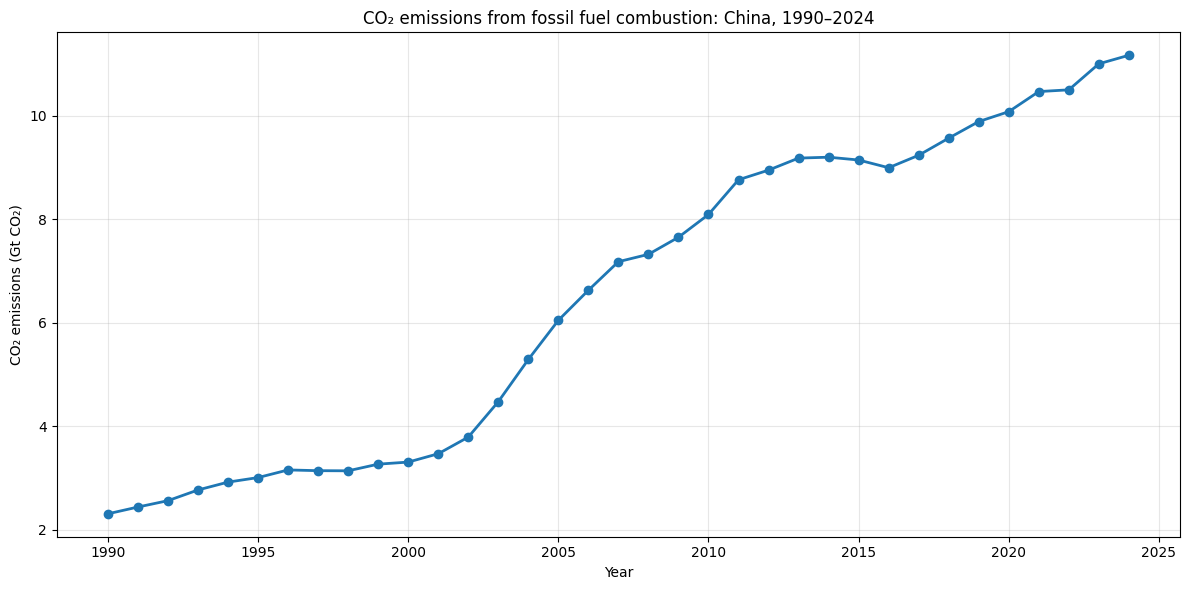

In [ ]:
co2_plot = kaya[["year", "co2_mt"]].dropna().copy()
co2_plot["co2_gt"] = co2_plot["co2_mt"] / 1000

plt.figure(figsize=(12, 6))

plt.plot(
    co2_plot["year"],
    co2_plot["co2_gt"],
    marker="o",
    linewidth=2
)

plt.title("CO₂ emissions from fossil fuel combustion: China, 1990–2024")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions (Gt CO₂)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
[c for c in sorted(ei["Country"].unique()) if "US" in c or "America" in c or "States" in c]

['Other North America',
 'Other S. & Cent. America',
 'Other South America',
 'Total Central America',
 'Total North America',
 'Total S. & Cent. America',
 'US',
 'USSR']

In [ ]:
country_name = "US"
country_code_wb = "USA"

In [ ]:
usa_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

usa_ei[["Country", "Year", "Var", "Value"]].head(10)

,Country,Year,Var,Value
279998,US,1965,co2_combust_mtco2,3451.891864
280033,US,1965,tes_ej,50.581347
280039,US,1966,co2_combust_mtco2,3639.794981
280074,US,1966,tes_ej,53.483057
280080,US,1967,co2_combust_mtco2,3738.161259
280115,US,1967,tes_ej,55.208237
280121,US,1968,co2_combust_mtco2,3947.343514
280156,US,1968,tes_ej,58.594754
280162,US,1969,co2_combust_mtco2,4117.396218
280197,US,1969,tes_ej,61.514629


In [ ]:
usa_ei = usa_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

usa_ei.head()

Var,Year,co2_combust_mtco2,tes_ej
0,1965,3451.891864,50.581347
1,1966,3639.794981,53.483057
2,1967,3738.161259,55.208237
3,1968,3947.343514,58.594754
4,1969,4117.396218,61.514629


In [ ]:
usa_ei = usa_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

usa_ei.head()

Var,year,co2_mt,energy_ej
0,1965,3451.891864,50.581347
1,1966,3639.794981,53.483057
2,1967,3738.161259,55.208237
3,1968,3947.343514,58.594754
4,1969,4117.396218,61.514629


In [ ]:
usa_ei.columns.tolist()

['year', 'co2_mt', 'energy_ej']

In [ ]:
['year', 'co2_mt', 'energy_ej']

['year', 'co2_mt', 'energy_ej']

In [ ]:
country_code_wb = "USA"

url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_usa = pd.DataFrame(data)

gdp_real_usa = gdp_real_usa[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_usa["year"] = gdp_real_usa["year"].astype(int)
gdp_real_usa = gdp_real_usa.sort_values("year")

gdp_real_usa.head(), gdp_real_usa.tail()

(    year  gdp_real_2015_usd
 34  1990       9.737637e+12
 33  1991       9.727089e+12
 32  1992       1.006973e+13
 31  1993       1.034682e+13
 30  1994       1.076370e+13,
    year  gdp_real_2015_usd
 4  2020       1.962763e+13
 3  2021       2.081610e+13
 2  2022       2.133907e+13
 1  2023       2.195525e+13
 0  2024       2.256846e+13)

In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_usa = pd.DataFrame(data)

pop_usa = pop_usa[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_usa["year"] = pop_usa["year"].astype(int)
pop_usa = pop_usa.sort_values("year")

pop_usa.head(), pop_usa.tail()

(    year  population
 34  1990   249623000
 33  1991   252981000
 32  1992   256514000
 31  1993   259919000
 30  1994   263126000,
    year  population
 4  2020   331577720
 3  2021   332099760
 2  2022   334017321
 1  2023   336806231
 0  2024   340110988)

In [ ]:
usa = pd.merge(gdp_real_usa, pop_usa, on="year", how="inner")
usa = pd.merge(usa, usa_ei, on="year", how="inner")

usa = usa.sort_values("year").copy()

usa.head(), usa.tail()

(   year  gdp_real_2015_usd  population       co2_mt  energy_ej
 0  1990       9.737637e+12   249623000  4971.209525  80.127813
 1  1991       9.727089e+12   252981000  4923.568110  80.093747
 2  1992       1.006973e+13   256514000  5005.970740  81.554633
 3  1993       1.034682e+13   259919000  5119.325964  83.107709
 4  1994       1.076370e+13   263126000  5196.431493  84.772104,
     year  gdp_real_2015_usd  population       co2_mt  energy_ej
 30  2020       1.962763e+13   331577720  4468.372662  86.213756
 31  2021       2.081610e+13   332099760  4755.310256  90.785549
 32  2022       2.133907e+13   334017321  4801.927576  92.251548
 33  2023       2.195525e+13   336806231  4642.749416  91.197763
 34  2024       2.256846e+13   340110988  4619.121942  91.832112)

In [ ]:
usa["gdp_per_capita"] = usa["gdp_real_2015_usd"] / usa["population"]
usa["energy_intensity"] = usa["energy_ej"] / usa["gdp_real_2015_usd"]
usa["carbon_intensity"] = usa["co2_mt"] / usa["energy_ej"]

usa[[
    "year",
    "population",
    "gdp_per_capita",
    "energy_intensity",
    "carbon_intensity",
    "co2_mt"
]].head()

,year,population,gdp_per_capita,energy_intensity,carbon_intensity,co2_mt
0,1990,249623000,39009.372508,8.228672e-12,62.040998,4971.209525
1,1991,252981000,38449.881528,8.234092e-12,61.472566,4923.568110
2,1992,256514000,39256.048133,8.098992e-12,61.381807,5005.970740
3,1993,259919000,39807.879503,8.032195e-12,61.598690,5119.325964
4,1994,263126000,40907.018435,7.875740e-12,61.298838,5196.431493


In [ ]:
usa_kaya = usa[(usa["year"] >= 1990) & (usa["year"] <= 2024)].copy()

usa_kaya["population_pp"] = 100 * np.log(usa_kaya["population"] / usa_kaya["population"].shift(1))
usa_kaya["gdp_per_capita_pp"] = 100 * np.log(usa_kaya["gdp_per_capita"] / usa_kaya["gdp_per_capita"].shift(1))
usa_kaya["energy_intensity_pp"] = 100 * np.log(usa_kaya["energy_intensity"] / usa_kaya["energy_intensity"].shift(1))
usa_kaya["carbon_intensity_pp"] = 100 * np.log(usa_kaya["carbon_intensity"] / usa_kaya["carbon_intensity"].shift(1))

usa_kaya["co2_growth_pct"] = 100 * np.log(usa_kaya["co2_mt"] / usa_kaya["co2_mt"].shift(1))

usa_kaya["sum_factors"] = (
    usa_kaya["population_pp"] +
    usa_kaya["gdp_per_capita_pp"] +
    usa_kaya["energy_intensity_pp"] +
    usa_kaya["carbon_intensity_pp"]
)

usa_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,-0.962968,-0.962968,1.336261,-1.444632,0.065847,-0.920444
2,1992,1.659785,1.659785,1.386886,2.074991,-1.654341,-0.147750
3,1993,2.239143,2.239143,1.318680,1.395935,-0.828182,0.352710
4,1994,1.494936,1.494936,1.226296,2.723678,-1.967068,-0.487971
5,1995,0.616980,0.616980,1.190787,1.458245,-0.927654,-1.104398
6,1996,3.387544,3.387544,1.163412,2.539933,-0.588276,0.272476
7,1997,1.383495,1.383495,1.203960,3.147120,-3.682875,0.715290
8,1998,0.731866,0.731866,1.165715,3.219832,-3.442844,-0.210837
9,1999,0.896561,0.896561,1.148340,3.528973,-2.819741,-0.961011


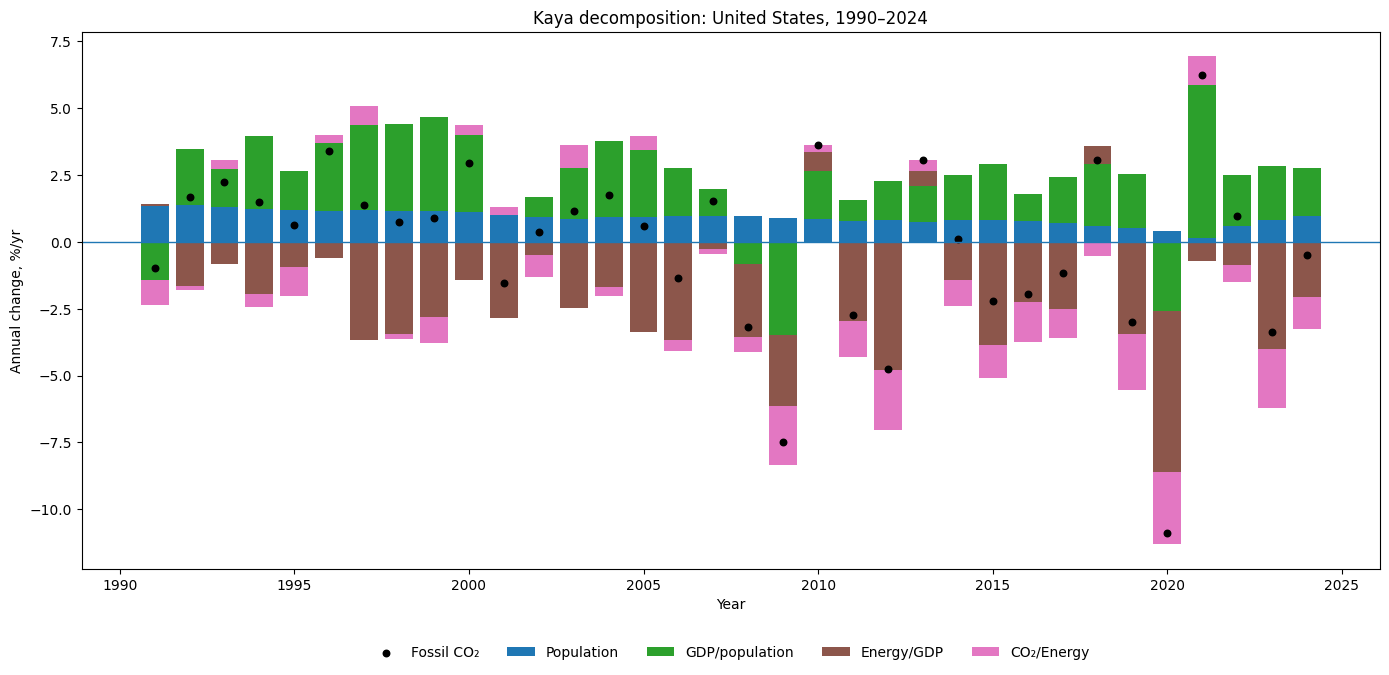

In [ ]:
plot = usa_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: United States, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(
    "usa_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [ ]:
kaya.to_csv("china_kaya_1990_2024.csv", index=False)
usa_kaya.to_csv("usa_kaya_1990_2024.csv", index=False)
usa.to_csv("usa_full_dataset.csv", index=False)
df.to_csv("china_full_dataset.csv", index=False)

First, let's combine all the Kaya data for the 9 countries (China, USA, UK, Germany, Czechia, Austria, Japan, India, EU27) into a single DataFrame. I will also rename the columns to match the `plot_kaya_panel` function's expected input.

Now, let's create a combined plot with 9 subplots (3 rows, 3 columns) for all the countries, using the `plot_kaya_panel` function and a common legend.

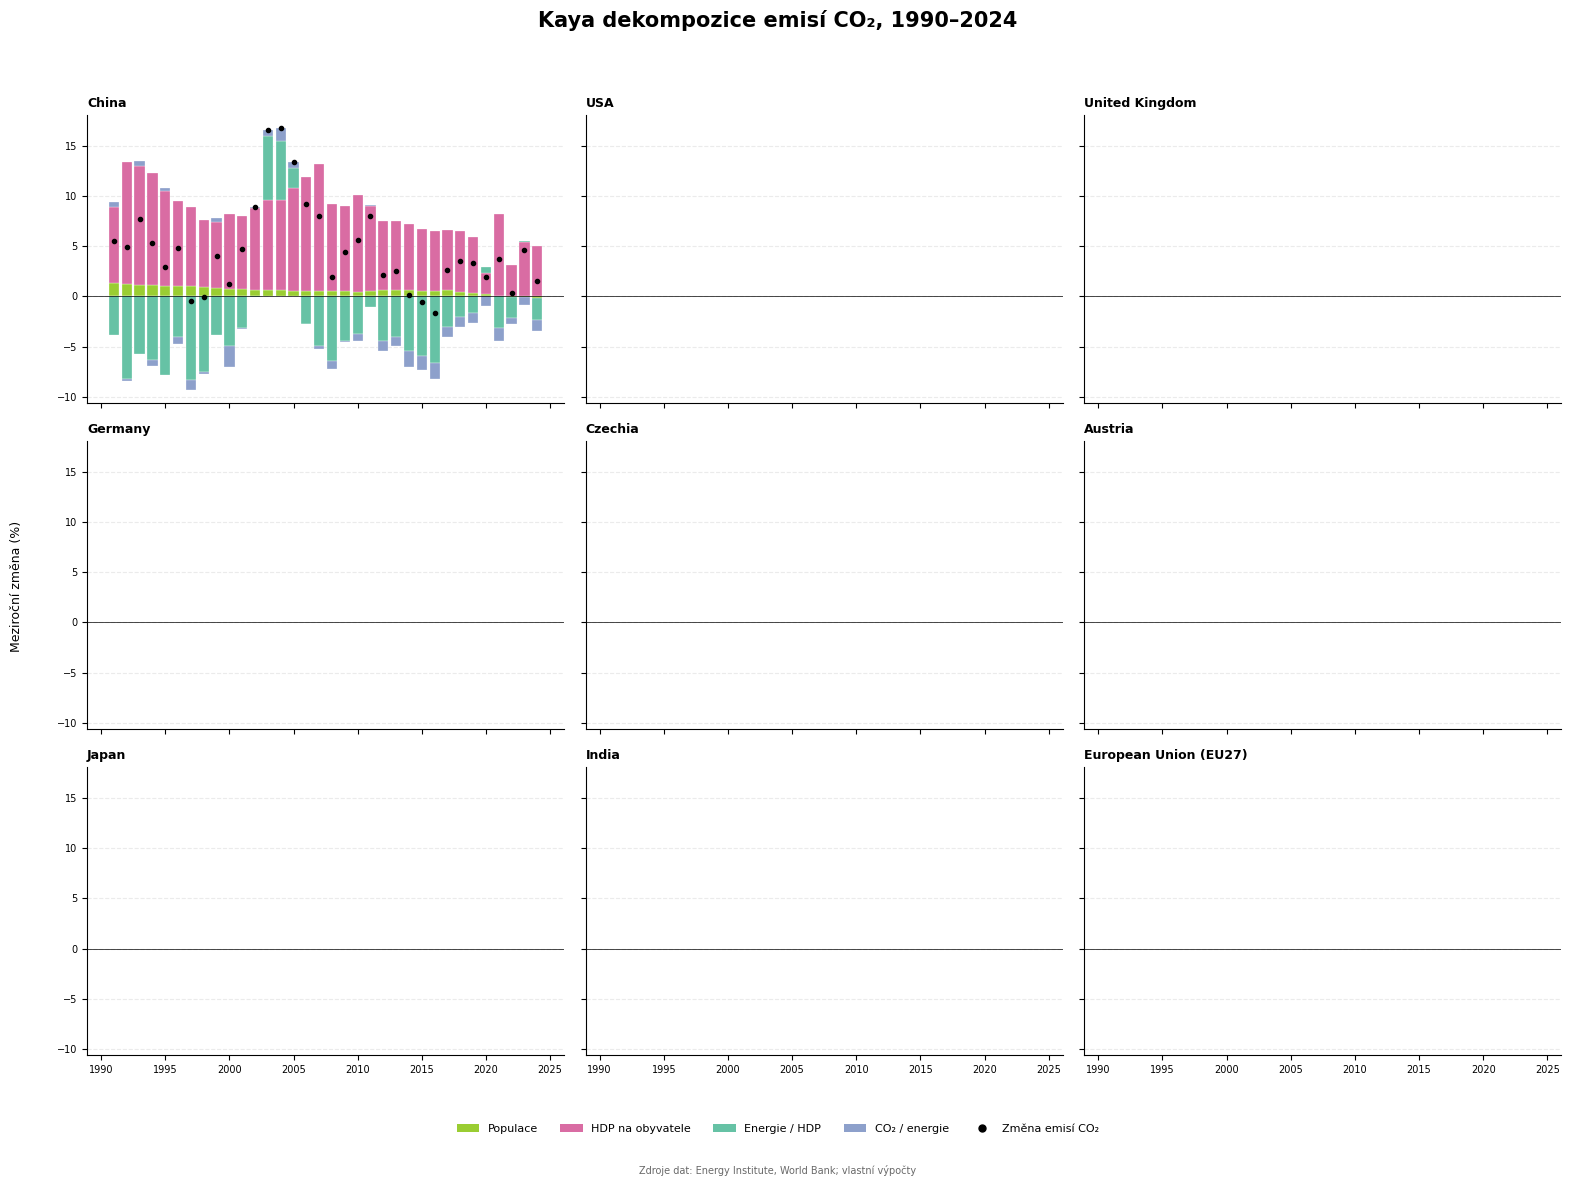

In [ ]:
# Create the 'figures' directory if it doesn't exist
output_dir = "figures"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

fig, axes = plt.subplots(
    3, 3, # 3 rows, 3 columns to accommodate 9 plots
    figsize=(16, 12), # Adjust figure size for better readability
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# Get unique country names to iterate through from the combined_kaya_plots DataFrame
unique_countries = combined_kaya_plots["country"].unique()
num_countries = len(unique_countries)
num_subplots = len(axes)

# Plot each country using the data from combined_kaya_plots with correct column names
for i, country_name in enumerate(unique_countries):
    if i < num_subplots:
        data_for_plot = combined_kaya_plots[combined_kaya_plots["country"] == country_name]
        plot_kaya_panel(axes[i], data_for_plot, country_name)
    else:
        break

# Turn off any unused subplots if num_subplots > num_countries
for j in range(num_countries, num_subplots):
    if j < len(axes):
        fig.delaxes(axes[j])

fig.suptitle(
    "Kaya dekompozice emisí CO₂, 1990–2024",
    fontsize=15,
    weight="bold",
    y=0.98
)

fig.text(
    0.02,
    0.5,
    "Meziroční změna (%)",
    va="center",
    rotation="vertical",
    fontsize=9
)

legend_elements = [
    Patch(facecolor="#9ACD32", label="Populace"),
    Patch(facecolor="#D96CA3", label="HDP na obyvatele"),
    Patch(facecolor="#66C2A5", label="Energie / HDP"),
    Patch(facecolor="#8DA0CB", label="CO₂ / energie"),
    Line2D(
        [0], [0],
        marker="o",
        color="black",
        linestyle="None",
        markersize=5,
        label="Změna emisí CO₂"
    )
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.5, 0.035)
)

fig.text(
    0.5,
    0.01,
    "Zdroje dat: Energy Institute, World Bank; vlastní výpočty",
    ha="center",
    fontsize=7,
    color="dimgray"
)

plt.tight_layout(rect=[0.04, 0.08, 1, 0.95])

plt.savefig(
    os.path.join(output_dir, "kaya_decomposition_9_panels_A4.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(output_dir, "kaya_decomposition_9_panels_A4.pdf"),
    bbox_inches="tight"
)

plt.show()

In [ ]:
from google.colab import files

files.download("china_kaya_1990_2024.csv")
files.download("usa_kaya_1990_2024.csv")
files.download("china_full_dataset.csv")
files.download("usa_full_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("china_kaya_1990_2024.csv")
files.download("usa_kaya_1990_2024.csv")
files.download("china_full_dataset.csv")
files.download("usa_full_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

os.listdir()

['.config',
 'usa_full_dataset.csv',
 'usa_kaya_decomposition.png',
 '.ipynb_checkpoints',
 'usa_kaya_1990_2024.csv',
 'china_full_dataset.csv',
 'raw_data',
 'china_kaya_1990_2024.csv',
 'sample_data']

In [ ]:
country_name = "United Kingdom"
country_code_wb = "GBR"

In [ ]:
country_name = "United Kingdom"

uk_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

uk_ei[["Country", "Year", "Var", "Value"]].head(10)

,Country,Year,Var,Value
276616,United Kingdom,1965,co2_combust_mtco2,688.098035
276648,United Kingdom,1965,tes_ej,8.316421
276656,United Kingdom,1966,co2_combust_mtco2,680.946946
276688,United Kingdom,1966,tes_ej,8.361074
276696,United Kingdom,1967,co2_combust_mtco2,670.097427
276728,United Kingdom,1967,tes_ej,8.363311
276736,United Kingdom,1968,co2_combust_mtco2,689.743000
276768,United Kingdom,1968,tes_ej,8.673082
276776,United Kingdom,1969,co2_combust_mtco2,707.625731
276809,United Kingdom,1969,tes_ej,8.992704


In [ ]:
uk_ei = uk_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

uk_ei = uk_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

uk_ei.head()

Var,year,co2_mt,energy_ej
0,1965,688.098035,8.316421
1,1966,680.946946,8.361074
2,1967,670.097427,8.363311
3,1968,689.743000,8.673082
4,1969,707.625731,8.992704


In [ ]:
country_code_wb = "GBR"

url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_uk = pd.DataFrame(data)

gdp_real_uk = gdp_real_uk[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_uk["year"] = gdp_real_uk["year"].astype(int)
gdp_real_uk = gdp_real_uk.sort_values("year")

gdp_real_uk.head(), gdp_real_uk.tail()

(    year  gdp_real_2015_usd
 34  1990       1.721504e+12
 33  1991       1.699255e+12
 32  1992       1.721255e+12
 31  1993       1.781336e+12
 30  1994       1.869573e+12,
    year  gdp_real_2015_usd
 4  2020       2.868822e+12
 3  2021       3.113908e+12
 2  2022       3.274265e+12
 1  2023       3.283160e+12
 0  2024       3.320142e+12)

In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_uk = pd.DataFrame(data)

pop_uk = pop_uk[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_uk["year"] = pop_uk["year"].astype(int)
pop_uk = pop_uk.sort_values("year")

pop_uk.head(), pop_uk.tail()

(    year  population
 34  1990    57247586
 33  1991    57424897
 32  1992    57580402
 31  1993    57718614
 30  1994    57865745,
    year  population
 4  2020    66744000
 3  2021    66984000
 2  2022    67604000
 1  2023    68492000
 0  2024    69226000)

In [ ]:
uk = pd.merge(gdp_real_uk, pop_uk, on="year", how="inner")
uk = pd.merge(uk, uk_ei, on="year", how="inner")
uk = uk.sort_values("year").copy()

uk["gdp_per_capita"] = uk["gdp_real_2015_usd"] / uk["population"]
uk["energy_intensity"] = uk["energy_ej"] / uk["gdp_real_2015_usd"]
uk["carbon_intensity"] = uk["co2_mt"] / uk["energy_ej"]

uk_kaya = uk[(uk["year"] >= 1990) & (uk["year"] <= 2024)].copy()

uk_kaya["population_pp"] = 100 * np.log(uk_kaya["population"] / uk_kaya["population"].shift(1))
uk_kaya["gdp_per_capita_pp"] = 100 * np.log(uk_kaya["gdp_per_capita"] / uk_kaya["gdp_per_capita"].shift(1))
uk_kaya["energy_intensity_pp"] = 100 * np.log(uk_kaya["energy_intensity"] / uk_kaya["energy_intensity"].shift(1))
uk_kaya["carbon_intensity_pp"] = 100 * np.log(uk_kaya["carbon_intensity"] / uk_kaya["carbon_intensity"].shift(1))

uk_kaya["co2_growth_pct"] = 100 * np.log(uk_kaya["co2_mt"] / uk_kaya["co2_mt"].shift(1))

uk_kaya["sum_factors"] = (
    uk_kaya["population_pp"] +
    uk_kaya["gdp_per_capita_pp"] +
    uk_kaya["energy_intensity_pp"] +
    uk_kaya["carbon_intensity_pp"]
)

uk_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,1.715999,1.715999,0.309248,-1.610112,3.462587,-0.445724
2,1992,-2.831299,-2.831299,0.270431,1.015987,-1.926143,-2.191575
3,1993,-2.398632,-2.398632,0.239745,3.191206,-2.126975,-3.702608
4,1994,-2.335433,-2.335433,0.254586,4.580050,-6.120580,-1.049490
5,1995,-0.457914,-0.457914,0.264547,3.207852,-3.094657,-0.835656
6,1996,3.615281,3.615281,0.254626,2.326685,2.264792,-1.230823
7,1997,-3.426780,-3.426780,0.257553,4.507098,-6.566776,-1.624656
8,1998,0.069497,0.069497,0.291406,2.903329,-2.440897,-0.684341
9,1999,-1.653464,-1.653464,0.333406,2.568536,-3.420055,-1.135351


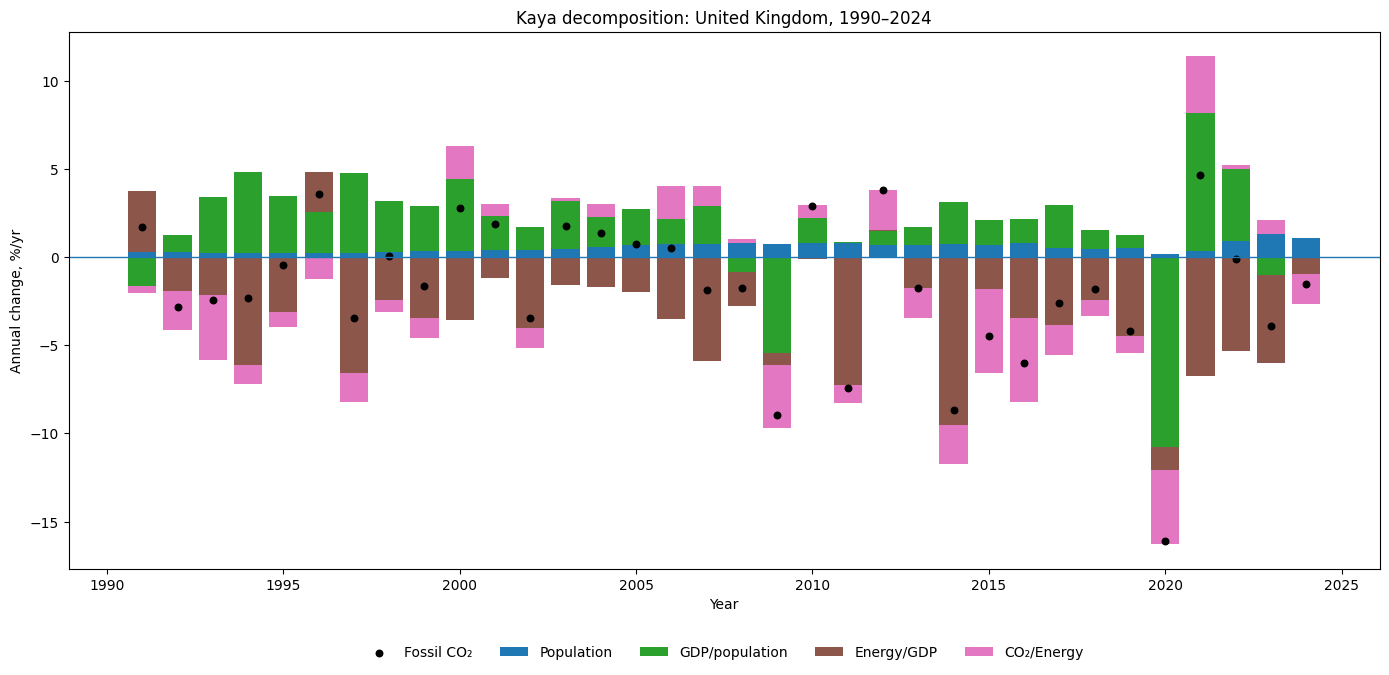

In [ ]:
plot = uk_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: United Kingdom, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "uk_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
country_name = "Germany"
country_code_wb = "DEU"

In [ ]:
country_name = "Germany"

germany_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

germany_ei[["Country", "Year", "Var", "Value"]].head(10)

,Country,Year,Var,Value
61074,Germany,1965,co2_combust_mtco2,910.413862
61098,Germany,1965,tes_ej,10.575319
61102,Germany,1966,co2_combust_mtco2,901.037825
61126,Germany,1966,tes_ej,10.593859
61130,Germany,1967,co2_combust_mtco2,892.416100
61154,Germany,1967,tes_ej,10.573485
61158,Germany,1968,co2_combust_mtco2,944.755407
61182,Germany,1968,tes_ej,11.295655
61186,Germany,1969,co2_combust_mtco2,1011.924353
61210,Germany,1969,tes_ej,12.218014


In [ ]:
germany_ei = germany_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

germany_ei = germany_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

germany_ei.head()

Var,year,co2_mt,energy_ej
0,1965,910.413862,10.575319
1,1966,901.037825,10.593859
2,1967,892.416100,10.573485
3,1968,944.755407,11.295655
4,1969,1011.924353,12.218014


In [ ]:
country_code_wb = "DEU"

url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_germany = pd.DataFrame(data)

gdp_real_germany = gdp_real_germany[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_germany["year"] = gdp_real_germany["year"].astype(int)
gdp_real_germany = gdp_real_germany.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_germany = pd.DataFrame(data)

pop_germany = pop_germany[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_germany["year"] = pop_germany["year"].astype(int)
pop_germany = pop_germany.sort_values("year")

In [ ]:
germany = pd.merge(gdp_real_germany, pop_germany, on="year", how="inner")
germany = pd.merge(germany, germany_ei, on="year", how="inner")
germany = germany.sort_values("year").copy()

germany["gdp_per_capita"] = germany["gdp_real_2015_usd"] / germany["population"]
germany["energy_intensity"] = germany["energy_ej"] / germany["gdp_real_2015_usd"]
germany["carbon_intensity"] = germany["co2_mt"] / germany["energy_ej"]

germany_kaya = germany[(germany["year"] >= 1990) & (germany["year"] <= 2024)].copy()

germany_kaya["population_pp"] = 100 * np.log(germany_kaya["population"] / germany_kaya["population"].shift(1))
germany_kaya["gdp_per_capita_pp"] = 100 * np.log(germany_kaya["gdp_per_capita"] / germany_kaya["gdp_per_capita"].shift(1))
germany_kaya["energy_intensity_pp"] = 100 * np.log(germany_kaya["energy_intensity"] / germany_kaya["energy_intensity"].shift(1))
germany_kaya["carbon_intensity_pp"] = 100 * np.log(germany_kaya["carbon_intensity"] / germany_kaya["carbon_intensity"].shift(1))

germany_kaya["co2_growth_pct"] = 100 * np.log(germany_kaya["co2_mt"] / germany_kaya["co2_mt"].shift(1))

germany_kaya["sum_factors"] = (
    germany_kaya["population_pp"] +
    germany_kaya["gdp_per_capita_pp"] +
    germany_kaya["energy_intensity_pp"] +
    germany_kaya["carbon_intensity_pp"]
)

germany_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,-3.834232,-3.834232,0.728606,4.253464,-7.402508,-1.413794
2,1992,-4.858562,-4.858562,0.760347,1.233261,-4.092752,-2.759418
3,1993,-0.809071,-0.809071,0.657391,-1.635189,0.473788,-0.305060
4,1994,-2.133425,-2.133425,0.346857,2.216853,-3.595003,-1.102132
5,1995,-0.843131,-0.843131,0.293904,1.199877,-1.054910,-1.282002
6,1996,2.820598,2.820598,0.289475,0.743052,2.364474,-0.576403
7,1997,-2.978988,-2.978988,0.146313,1.691026,-3.142333,-1.673995
8,1998,-1.013819,-1.013819,0.015144,2.058813,-3.028159,-0.059617
9,1999,-2.665445,-2.665445,0.064635,2.042577,-3.612455,-1.160202


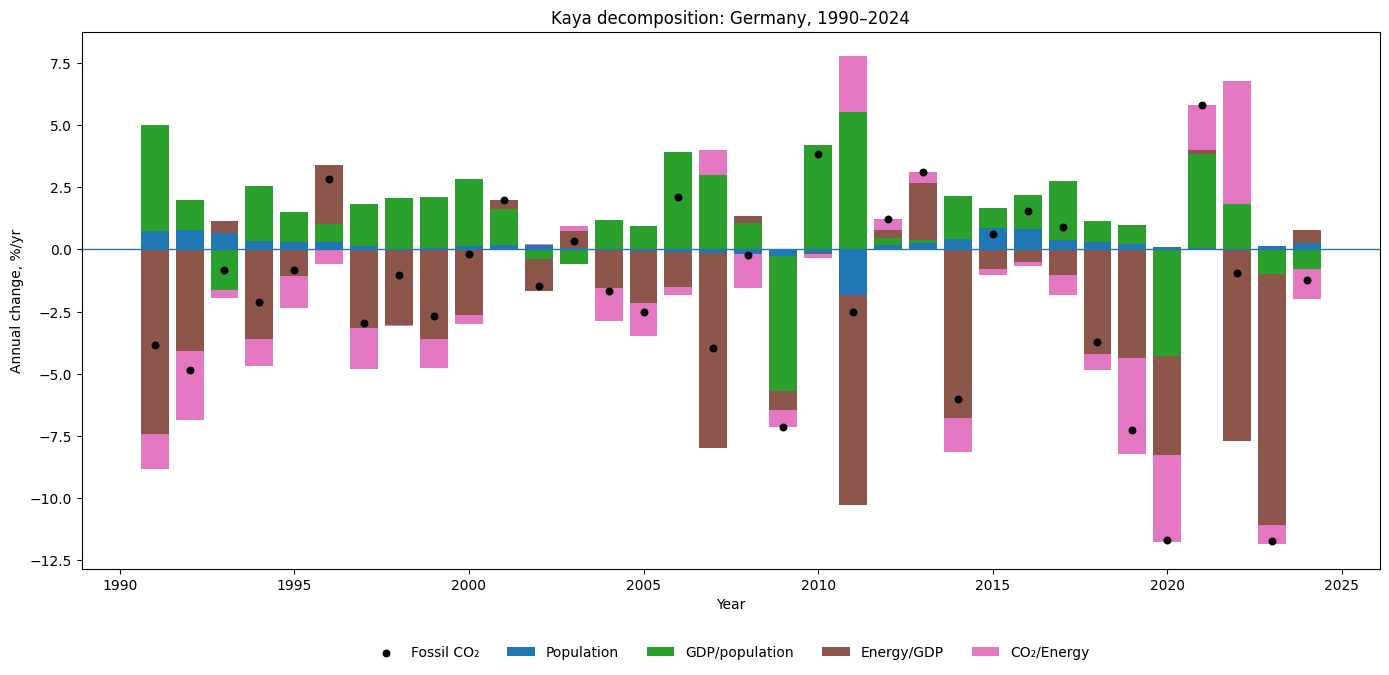

In [ ]:
plot = germany_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: Germany, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "germany_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
"germany_kaya" in globals()

True

In [ ]:
uk.to_csv("uk_full_dataset.csv", index=False)
uk_kaya.to_csv("uk_kaya_1990_2024.csv", index=False)

germany.to_csv("germany_full_dataset.csv", index=False)
germany_kaya.to_csv("germany_kaya_1990_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("uk_full_dataset.csv")
files.download("uk_kaya_1990_2024.csv")

files.download("germany_full_dataset.csv")
files.download("germany_kaya_1990_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plot = usa.copy().sort_values("year")
plot = plot[(plot["year"] >= 1990) & (plot["year"] <= 2024)].copy()

# běžné meziroční procentní změny, ne logaritmické
plot["population_pct"] = plot["population"].pct_change() * 100
plot["gdp_per_capita_pct"] = plot["gdp_per_capita"].pct_change() * 100
plot["energy_intensity_pct"] = plot["energy_intensity"].pct_change() * 100
plot["carbon_intensity_pct"] = plot["carbon_intensity"].pct_change() * 100
plot["co2_pct"] = plot["co2_mt"].pct_change() * 100

# šedá interakce / zbytek
plot["interactions_pct"] = (
    plot["co2_pct"]
    - plot["population_pct"]
    - plot["gdp_per_capita_pct"]
    - plot["energy_intensity_pct"]
    - plot["carbon_intensity_pct"]
)

plot = plot.dropna()

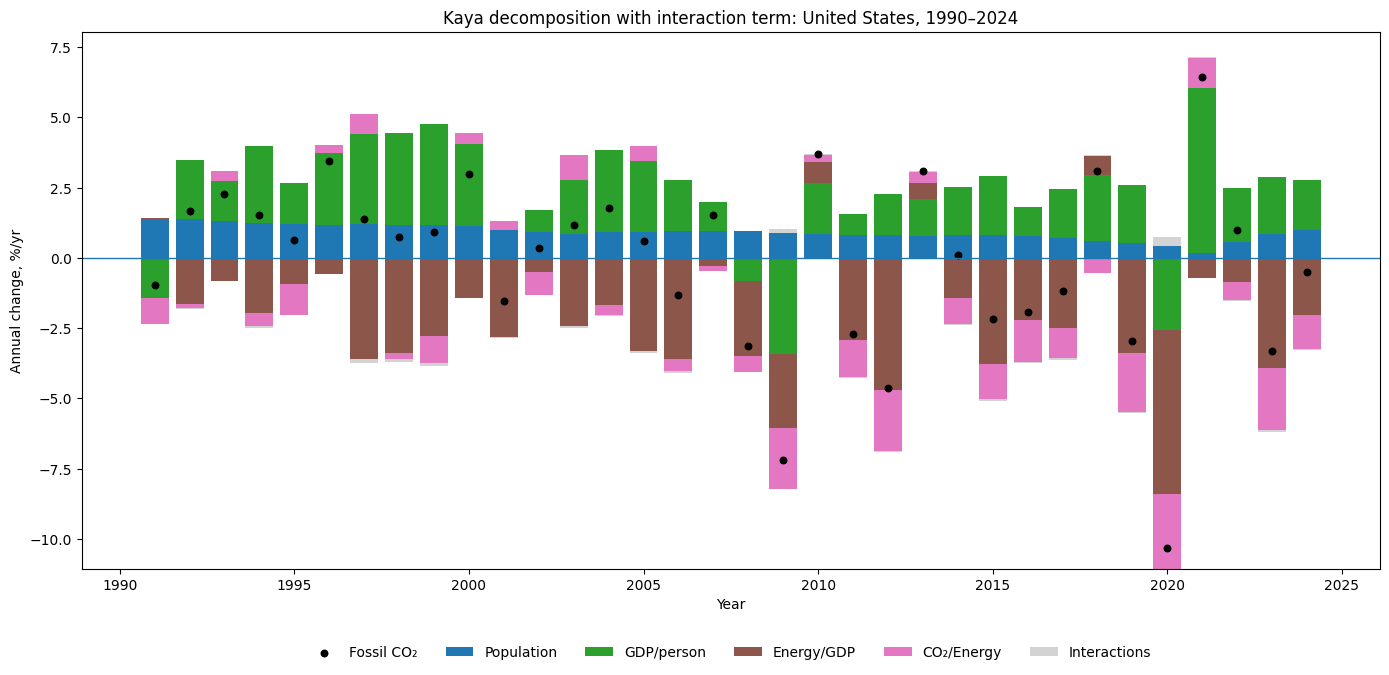

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pct", "Population", "tab:blue"),
    ("gdp_per_capita_pct", "GDP/person", "tab:green"),
    ("energy_intensity_pct", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pct", "CO₂/Energy", "tab:pink"),
    ("interactions_pct", "Interactions", "lightgrey")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition with interaction term: United States, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=6,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "us_kaya_decomposition_with_interactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

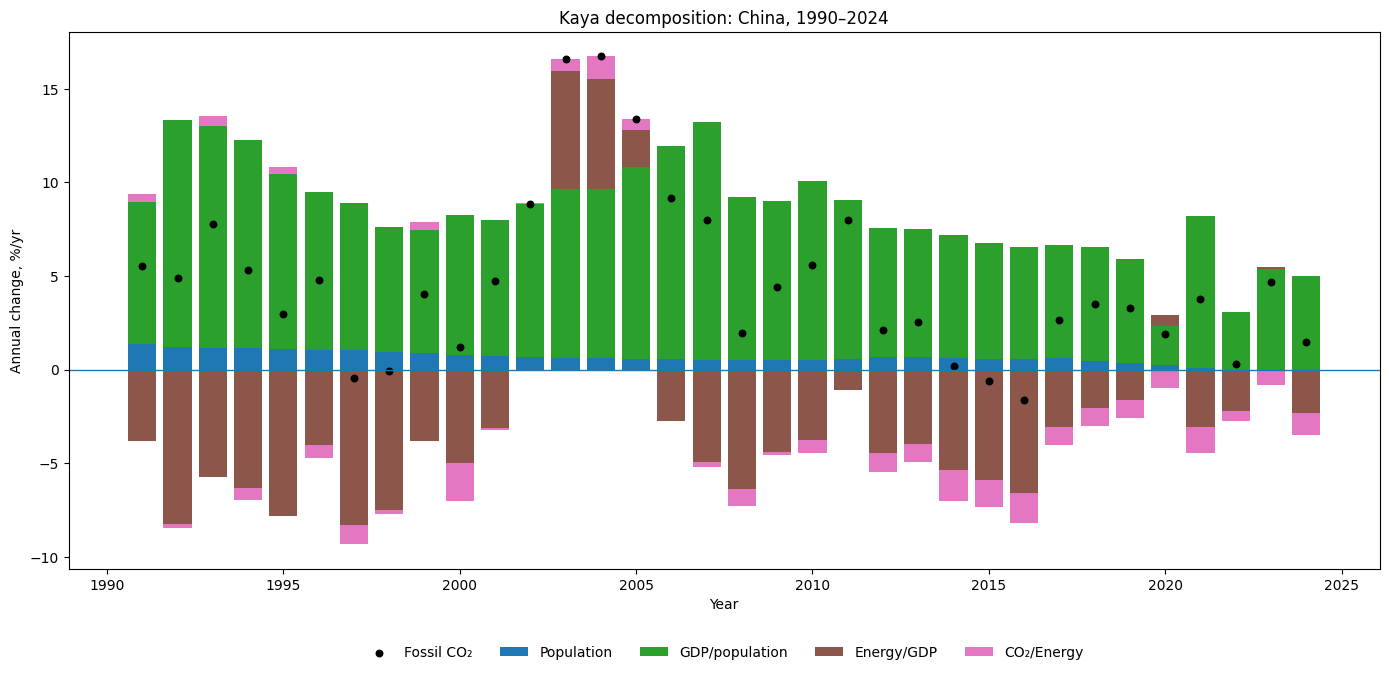

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot = kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: China, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(
    "china_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [ ]:
country_name = "United Arab Emirates"
country_code_wb = "ARE"

In [ ]:
country_name = "United Arab Emirates"
country_code_wb = "ARE"

uae_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

uae_ei = uae_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

uae_ei = uae_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

uae_ei.head()

Var,year,co2_mt,energy_ej
0,1965,0.218804,0.003076
1,1966,0.233529,0.003283
2,1967,1.144920,0.019464
3,1968,1.461773,0.025001
4,1969,1.473252,0.025088


In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_uae = pd.DataFrame(data)

gdp_real_uae = gdp_real_uae[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_uae["year"] = gdp_real_uae["year"].astype(int)
gdp_real_uae = gdp_real_uae.sort_values("year")

gdp_real_uae.head(), gdp_real_uae.tail()

(    year  gdp_real_2015_usd
 34  1990       1.261967e+11
 33  1991       1.272821e+11
 32  1992       1.315396e+11
 31  1993       1.331986e+11
 30  1994       1.423842e+11,
    year  gdp_real_2015_usd
 4  2020       3.748991e+11
 3  2021       3.919674e+11
 2  2022       4.214217e+11
 1  2023       4.395478e+11
 0  2024       4.570938e+11)

In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_uae = pd.DataFrame(data)

gdp_real_uae = gdp_real_uae[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_uae["year"] = gdp_real_uae["year"].astype(int)
gdp_real_uae = gdp_real_uae.sort_values("year")

gdp_real_uae.head(), gdp_real_uae.tail()

(    year  gdp_real_2015_usd
 34  1990       1.261967e+11
 33  1991       1.272821e+11
 32  1992       1.315396e+11
 31  1993       1.331986e+11
 30  1994       1.423842e+11,
    year  gdp_real_2015_usd
 4  2020       3.748991e+11
 3  2021       3.919674e+11
 2  2022       4.214217e+11
 1  2023       4.395478e+11
 0  2024       4.570938e+11)

In [ ]:
uae_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

uae_ei = uae_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

uae_ei = uae_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

uae_ei.head()

Var,year,co2_mt,energy_ej
0,1965,0.218804,0.003076
1,1966,0.233529,0.003283
2,1967,1.144920,0.019464
3,1968,1.461773,0.025001
4,1969,1.473252,0.025088


In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_uae = pd.DataFrame(data)

gdp_real_uae = gdp_real_uae[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_uae["year"] = gdp_real_uae["year"].astype(int)
gdp_real_uae = gdp_real_uae.sort_values("year")

gdp_real_uae.head(), gdp_real_uae.tail()

(    year  gdp_real_2015_usd
 34  1990       1.261967e+11
 33  1991       1.272821e+11
 32  1992       1.315396e+11
 31  1993       1.331986e+11
 30  1994       1.423842e+11,
    year  gdp_real_2015_usd
 4  2020       3.748991e+11
 3  2021       3.919674e+11
 2  2022       4.214217e+11
 1  2023       4.395478e+11
 0  2024       4.570938e+11)

In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_uae = pd.DataFrame(data)

pop_uae = pop_uae[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_uae["year"] = pop_uae["year"].astype(int)
pop_uae = pop_uae.sort_values("year")

pop_uae.head(), pop_uae.tail()

(    year  population
 34  1990     1898220
 33  1991     2006626
 32  1992     2114730
 31  1993     2222093
 30  1994     2328188,
    year  population
 4  2020     9401038
 3  2021     9575152
 2  2022    10074977
 1  2023    10483751
 0  2024    10986400)

In [ ]:
uae = pd.merge(gdp_real_uae, pop_uae, on="year", how="inner")
uae = pd.merge(uae, uae_ei, on="year", how="inner")

In [ ]:
uae = pd.merge(gdp_real_uae, pop_uae, on="year", how="inner")
uae = pd.merge(uae, uae_ei, on="year", how="inner")
uae = uae.sort_values("year").copy()

uae["gdp_per_capita"] = uae["gdp_real_2015_usd"] / uae["population"]
uae["energy_intensity"] = uae["energy_ej"] / uae["gdp_real_2015_usd"]
uae["carbon_intensity"] = uae["co2_mt"] / uae["energy_ej"]

uae.head(), uae.tail()

(   year  gdp_real_2015_usd  population      co2_mt  energy_ej  gdp_per_capita  \
 0  1990       1.261967e+11     1898220   81.694236   1.241830    66481.613764   
 1  1991       1.272821e+11     2006626  100.243774   1.515015    63430.915459   
 2  1992       1.315396e+11     2114730   97.520043   1.464104    62201.624336   
 3  1993       1.331986e+11     2222093  101.392691   1.524493    59942.858861   
 4  1994       1.423842e+11     2328188  110.629331   1.672827    61156.650962   
 
    energy_intensity  carbon_intensity  
 0      9.840427e-12         65.785377  
 1      1.190281e-11         66.166862  
 2      1.113052e-11         66.607300  
 3      1.144526e-11         66.509110  
 4      1.174868e-11         66.133162  ,
     year  gdp_real_2015_usd  population      co2_mt  energy_ej  \
 30  2020       3.748991e+11     9401038  250.178582   4.238666   
 31  2021       3.919674e+11     9575152  260.990893   4.451486   
 32  2022       4.214217e+11    10074977  280.975101   4.8

In [ ]:
uae_kaya = uae[(uae["year"] >= 1990) & (uae["year"] <= 2024)].copy()

uae_kaya["population_pp"] = 100 * np.log(uae_kaya["population"] / uae_kaya["population"].shift(1))
uae_kaya["gdp_per_capita_pp"] = 100 * np.log(uae_kaya["gdp_per_capita"] / uae_kaya["gdp_per_capita"].shift(1))
uae_kaya["energy_intensity_pp"] = 100 * np.log(uae_kaya["energy_intensity"] / uae_kaya["energy_intensity"].shift(1))
uae_kaya["carbon_intensity_pp"] = 100 * np.log(uae_kaya["carbon_intensity"] / uae_kaya["carbon_intensity"].shift(1))

uae_kaya["co2_growth_pct"] = 100 * np.log(uae_kaya["co2_mt"] / uae_kaya["co2_mt"].shift(1))

uae_kaya["sum_factors"] = (
    uae_kaya["population_pp"] +
    uae_kaya["gdp_per_capita_pp"] +
    uae_kaya["energy_intensity_pp"] +
    uae_kaya["carbon_intensity_pp"]
)

uae_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,20.462151,20.462151,5.553810,-4.697406,19.027528,0.578218
2,1992,-2.754703,-2.754703,5.247244,-1.957025,-6.708363,0.663441
3,1993,3.894308,3.894308,4.952240,-3.698936,2.788529,-0.147525
4,1994,8.718425,8.718425,4.664074,2.004686,2.616526,-0.566862
5,1995,3.528397,3.528397,4.471766,2.001978,-2.219093,-0.726254
6,1996,2.075012,2.075012,6.476614,-0.840090,-2.626438,-0.935074
7,1997,3.902959,3.902959,8.124394,-0.252150,-3.608052,-0.361233
8,1998,2.012448,2.012448,7.617797,-7.326228,2.106584,-0.385704
9,1999,0.287551,0.287551,7.157276,-4.296379,-2.067201,-0.506145


In [ ]:
uae.to_csv("uae_full_dataset.csv", index=False)
uae_kaya.to_csv("uae_kaya_1990_2024.csv", index=False)

## Kaya decomposition for Czech Republic

In [ ]:
country_name = "Czechia"
country_code_wb = "CZE"

In [ ]:
cze_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

cze_ei = cze_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

cze_ei = cze_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

cze_ei.head()

Var,year,co2_mt,energy_ej
0,1965,156.201490,1.671878
1,1966,156.969636,1.685404
2,1967,153.764332,1.660428
3,1968,160.378977,1.735275
4,1969,167.235329,1.811481


In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_cze = pd.DataFrame(data)

gdp_real_cze = gdp_real_cze[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_cze["year"] = gdp_real_cze["year"].astype(int)
gdp_real_cze = gdp_real_cze.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_cze = pd.DataFrame(data)

pop_cze = pop_cze[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_cze["year"] = pop_cze["year"].astype(int)
pop_cze = pop_cze.sort_values("year")

gdp_real_cze.head(), pop_cze.head()

(    year  gdp_real_2015_usd
 34  1990       1.229730e+11
 33  1991       1.086897e+11
 32  1992       1.081392e+11
 31  1993       1.082061e+11
 30  1994       1.113542e+11,
     year  population
 34  1990    10333355
 33  1991    10308578
 32  1992    10319123
 31  1993    10329855
 30  1994    10333587)

In [ ]:
cze = pd.merge(gdp_real_cze, pop_cze, on="year", how="inner")
cze = pd.merge(cze, cze_ei, on="year", how="inner")
cze = cze.sort_values("year").copy()

cze["gdp_per_capita"] = cze["gdp_real_2015_usd"] / cze["population"]
cze["energy_intensity"] = cze["energy_ej"] / cze["gdp_real_2015_usd"]
cze["carbon_intensity"] = cze["co2_mt"] / cze["energy_ej"]

cze.head(), cze.tail()

(   year  gdp_real_2015_usd  population      co2_mt  energy_ej  gdp_per_capita  \
 0  1990       1.229730e+11    10333355  155.329376   1.968834    11900.584458   
 1  1991       1.086897e+11    10308578  143.210463   1.792249    10543.619598   
 2  1992       1.081392e+11    10319123  136.636152   1.737351    10479.491867   
 3  1993       1.082061e+11    10329855  134.087922   1.723170    10475.084915   
 4  1994       1.113542e+11    10333587  128.639054   1.677988    10775.944389   
 
    energy_intensity  carbon_intensity  
 0      1.601030e-11         78.894112  
 1      1.648959e-11         79.905471  
 2      1.606588e-11         78.646279  
 3      1.592489e-11         77.814666  
 4      1.506893e-11         76.662696  ,
     year  gdp_real_2015_usd  population     co2_mt  energy_ej  gdp_per_capita  \
 30  2020       2.057535e+11    10697858  88.433858   1.615633    19233.146955   
 31  2021       2.140433e+11    10505772  92.850023   1.703326    20373.878304   
 32  2022    

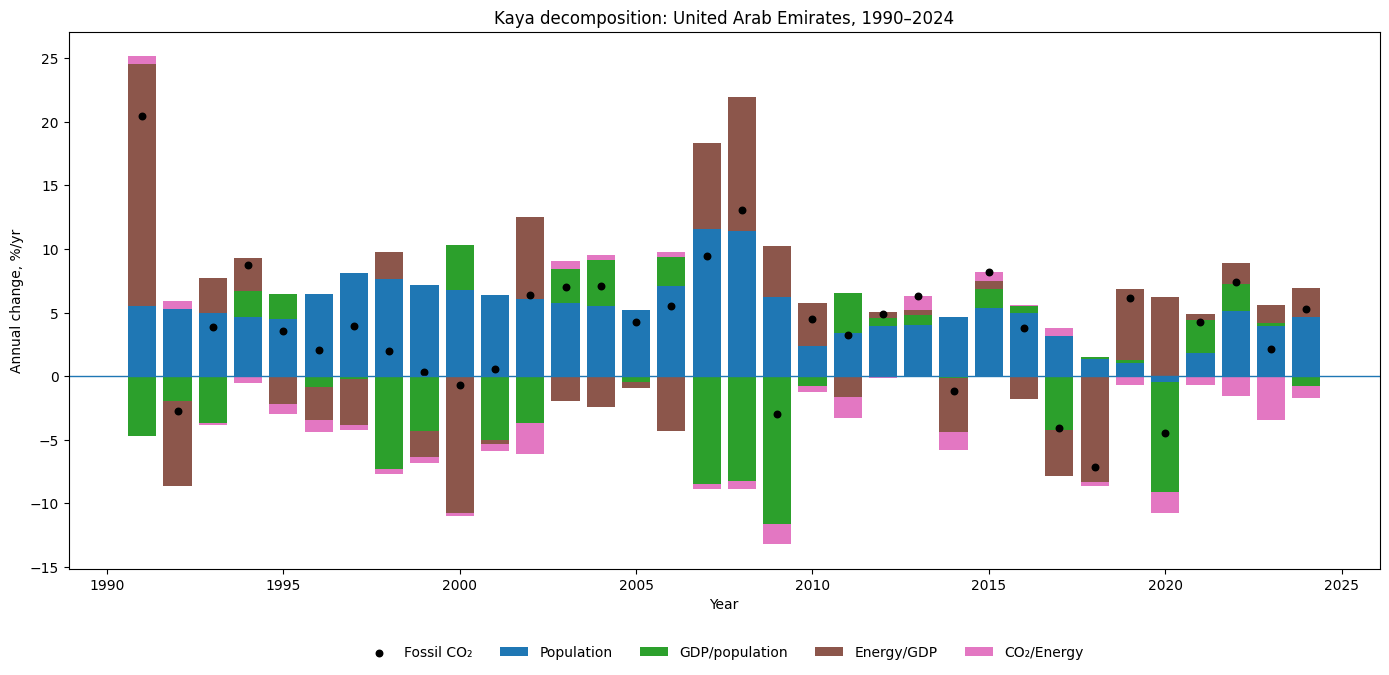

In [ ]:
plot = uae_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos,
           bottom=bottom_pos,
           label=label,
           color=color)

    ax.bar(plot["year"], neg,
           bottom=bottom_neg,
           color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: United Arab Emirates, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "uae_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_cze = pd.DataFrame(data)

gdp_real_cze = gdp_real_cze[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_cze["year"] = gdp_real_cze["year"].astype(int)
gdp_real_cze = gdp_real_cze.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_cze = pd.DataFrame(data)

pop_cze = pop_cze[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_cze["year"] = pop_cze["year"].astype(int)
pop_cze = pop_cze.sort_values("year")

cze = pd.merge(gdp_real_cze, pop_cze, on="year", how="inner")
cze = pd.merge(cze, cze_ei, on="year", how="inner")
cze = cze.sort_values("year").copy()

cze["gdp_per_capita"] = cze["gdp_real_2015_usd"] / cze["population"]
cze["energy_intensity"] = cze["energy_ej"] / cze["gdp_real_2015_usd"]
cze["carbon_intensity"] = cze["co2_mt"] / cze["energy_ej"]

cze_kaya = cze[(cze["year"] >= 1990) & (cze["year"] <= 2024)].copy()

cze_kaya["population_pp"] = 100 * np.log(cze_kaya["population"] / cze_kaya["population"].shift(1))
cze_kaya["gdp_per_capita_pp"] = 100 * np.log(cze_kaya["gdp_per_capita"] / cze_kaya["gdp_per_capita"].shift(1))
cze_kaya["energy_intensity_pp"] = 100 * np.log(cze_kaya["energy_intensity"] / cze_kaya["energy_intensity"].shift(1))
cze_kaya["carbon_intensity_pp"] = 100 * np.log(cze_kaya["carbon_intensity"] / cze_kaya["carbon_intensity"].shift(1))

cze_kaya["co2_growth_pct"] = 100 * np.log(cze_kaya["co2_mt"] / cze_kaya["co2_mt"].shift(1))

cze_kaya["sum_factors"] = (
    cze_kaya["population_pp"] +
    cze_kaya["gdp_per_capita_pp"] +
    cze_kaya["energy_intensity_pp"] +
    cze_kaya["carbon_intensity_pp"]
)

cze_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,-8.123255,-8.123255,-0.240065,-12.106661,2.949699,1.273772
2,1992,-4.699375,-4.699375,0.102241,-0.610071,-2.603144,-1.588401
3,1993,-1.882585,-1.882585,0.103947,-0.042062,-0.881431,-1.063039
4,1994,-4.148527,-4.148527,0.036122,2.831671,-5.524850,-1.491469
5,1995,1.191250,1.191250,-0.061314,6.096861,-2.147248,-2.697049
6,1996,2.050629,2.050629,-0.116381,4.200422,-0.653907,-1.379504
7,1997,-4.398843,-4.398843,-0.107763,-0.489858,-3.508474,-0.292748
8,1998,-4.430497,-4.430497,-0.094745,-0.299180,-2.416559,-1.620012
9,1999,-6.560322,-6.560322,-0.102176,1.471124,-5.696814,-2.232455


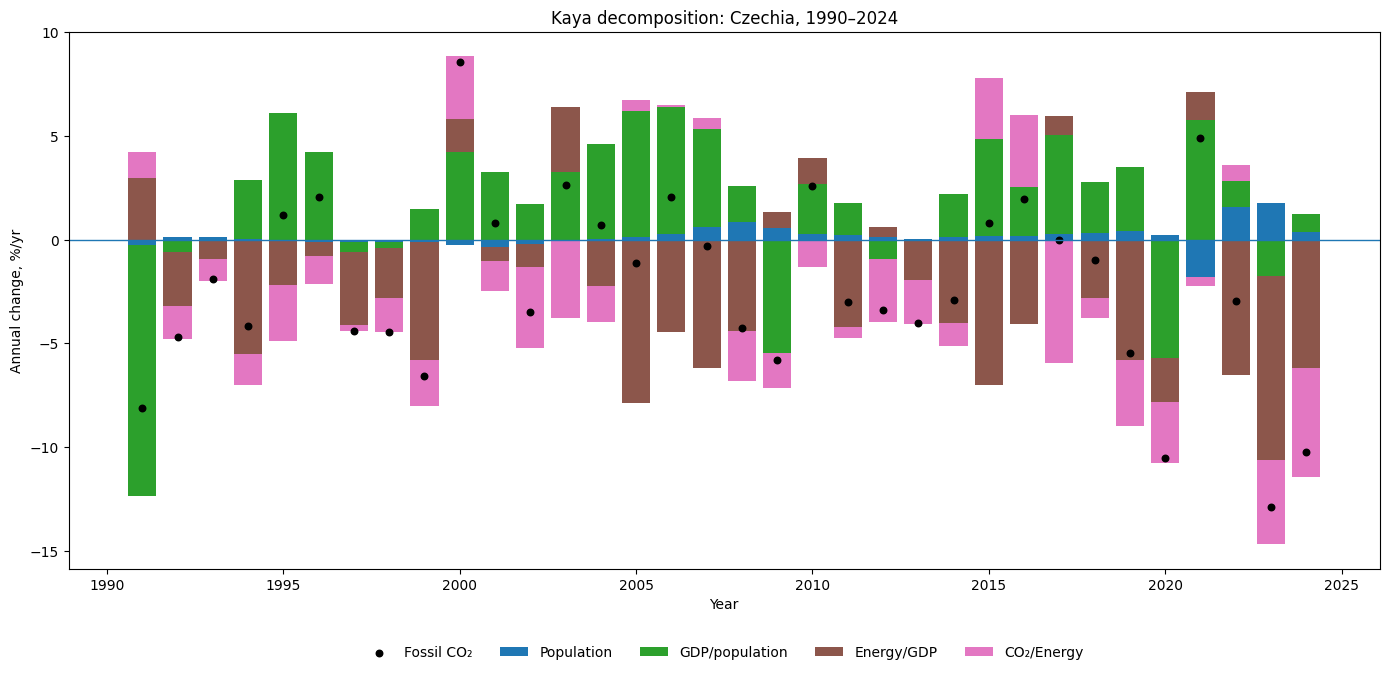

In [ ]:
plot = cze_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: Czechia, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(
    "cze_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
cze.to_csv("cze_full_dataset.csv", index=False)
cze_kaya.to_csv("cze_kaya_1990_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("cze_full_dataset.csv")
files.download("cze_kaya_1990_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Kaya decomposition for Austria

In [ ]:
country_name = "Austria"
country_code_wb = "AUT"

In [ ]:
aut_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

aut_ei = aut_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

aut_ei = aut_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

aut_ei.head()

Var,year,co2_mt,energy_ej
0,1965,39.529178,0.568886
1,1966,39.819097,0.591871
2,1967,40.112030,0.596623
3,1968,43.012020,0.643153
4,1969,46.052562,0.681154


In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_aut = pd.DataFrame(data)

gdp_real_aut = gdp_real_aut[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_aut["year"] = gdp_real_aut["year"].astype(int)
gdp_real_aut = gdp_real_aut.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_aut = pd.DataFrame(data)

pop_aut = pop_aut[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_aut["year"] = pop_aut["year"].astype(int)
pop_aut = pop_aut.sort_values("year")

gdp_real_aut.head(), pop_aut.head()

(    year  gdp_real_2015_usd
 34  1990       2.392970e+11
 33  1991       2.475327e+11
 32  1992       2.527148e+11
 31  1993       2.540462e+11
 30  1994       2.601487e+11,
     year  population
 34  1990     7677850
 33  1991     7754891
 32  1992     7840709
 31  1993     7905633
 30  1994     7936118)

In [ ]:
aut = pd.merge(gdp_real_aut, pop_aut, on="year", how="inner")
aut = pd.merge(aut, aut_ei, on="year", how="inner")
aut = aut.sort_values("year").copy()

aut["gdp_per_capita"] = aut["gdp_real_2015_usd"] / aut["population"]
aut["energy_intensity"] = aut["energy_ej"] / aut["gdp_real_2015_usd"]
aut["carbon_intensity"] = aut["co2_mt"] / aut["energy_ej"]

aut_kaya = aut[(aut["year"] >= 1990) & (aut["year"] <= 2024)].copy()

aut_kaya["population_pp"] = 100 * np.log(aut_kaya["population"] / aut_kaya["population"].shift(1))
aut_kaya["gdp_per_capita_pp"] = 100 * np.log(aut_kaya["gdp_per_capita"] / aut_kaya["gdp_per_capita"].shift(1))
aut_kaya["energy_intensity_pp"] = 100 * np.log(aut_kaya["energy_intensity"] / aut_kaya["energy_intensity"].shift(1))
aut_kaya["carbon_intensity_pp"] = 100 * np.log(aut_kaya["carbon_intensity"] / aut_kaya["carbon_intensity"].shift(1))

aut_kaya["co2_growth_pct"] = 100 * np.log(aut_kaya["co2_mt"] / aut_kaya["co2_mt"].shift(1))

aut_kaya["sum_factors"] = (
    aut_kaya["population_pp"] +
    aut_kaya["gdp_per_capita_pp"] +
    aut_kaya["energy_intensity_pp"] +
    aut_kaya["carbon_intensity_pp"]
)

aut_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,7.116602,7.116602,0.998418,2.385310,2.225229,1.507645
2,1992,-8.612157,-8.612157,1.100552,0.971359,-6.075068,-4.609000
3,1993,1.207597,1.207597,0.824628,-0.299201,0.914918,-0.232748
4,1994,0.282000,0.282000,0.384870,1.988852,-2.751631,0.659909
5,1995,5.527954,5.527954,0.153106,2.479908,2.762644,0.132296
6,1996,5.963348,5.963348,0.135020,2.056556,2.334479,1.437294
7,1997,-0.879050,-0.879050,0.113317,2.009820,-1.759444,-1.242742
8,1998,1.796957,1.796957,0.109728,3.323535,-1.343453,-0.292853
9,1999,-3.066034,-3.066034,0.194563,3.498327,-4.753443,-2.005481


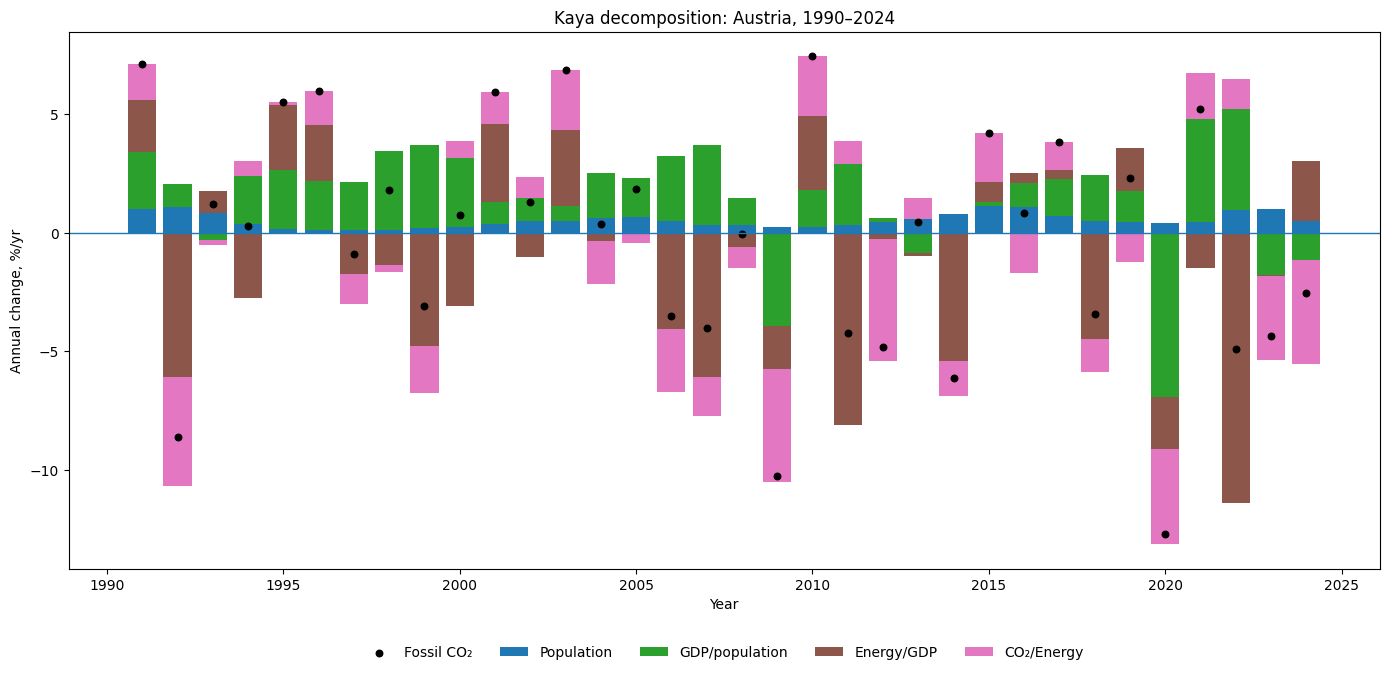

In [ ]:
plot = aut_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos,
           bottom=bottom_pos,
           label=label,
           color=color)

    ax.bar(plot["year"], neg,
           bottom=bottom_neg,
           color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: Austria, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "austria_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kaya decomposition for Austria Plot

![Kaya decomposition: Austria](austria_kaya_decomposition.png)

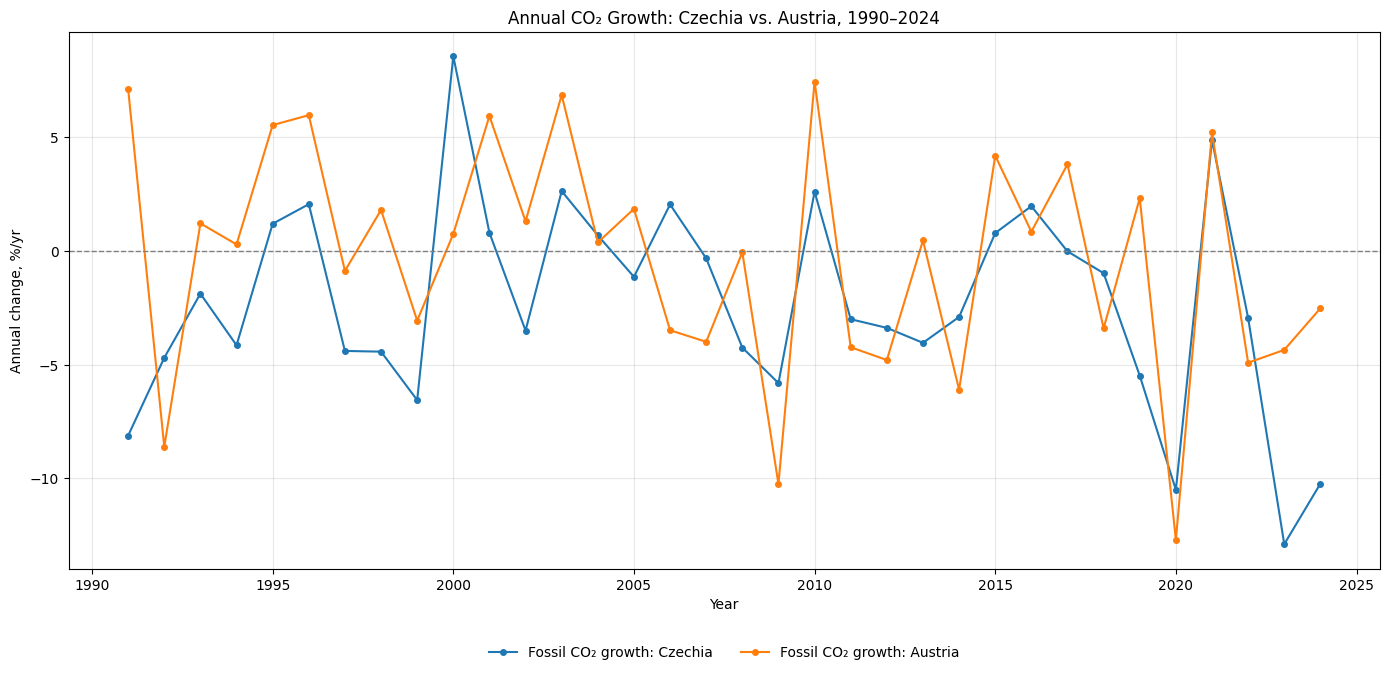

In [ ]:
cze_kaya["country"] = "Czechia"
aut_kaya["country"] = "Austria"

combined_kaya = pd.concat([cze_kaya, aut_kaya])

plt.figure(figsize=(14, 7))

for country in combined_kaya["country"].unique():
    country_data = combined_kaya[combined_kaya["country"] == country]
    plt.plot(
        country_data["year"],
        country_data["co2_growth_pct"],
        label=f"Fossil CO₂ growth: {country}",
        marker="o",
        markersize=4
    )

plt.axhline(0, linewidth=1, color='grey', linestyle='--')

plt.title("Annual CO₂ Growth: Czechia vs. Austria, 1990–2024")
plt.xlabel("Year")
plt.ylabel("Annual change, %/yr")
plt.grid(True, alpha=0.3)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(
    "cze_aut_co2_growth_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Annual CO₂ Growth: Czechia vs. Austria

![Annual CO₂ Growth: Czechia vs. Austria](cze_aut_co2_growth_comparison.png)

In [ ]:
aut.to_csv("austria_full_dataset.csv", index=False)
aut_kaya.to_csv("austria_kaya_1990_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("austria_full_dataset.csv")
files.download("austria_kaya_1990_2024.csv")
files.download("austria_kaya_decomposition.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Kaya decomposition for Japan

In [ ]:
country_name = "Japan"
country_code_wb = "JPN"

In [ ]:
japan_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

japan_ei = japan_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

japan_ei = japan_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

japan_ei.head()

Var,year,co2_mt,energy_ej
0,1965,445.343132,6.058706
1,1966,503.009880,6.925322
2,1967,576.544101,7.913075
3,1968,628.529144,8.732693
4,1969,728.688623,10.254458


In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_jpn = pd.DataFrame(data)

gdp_real_jpn = gdp_real_jpn[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_jpn["year"] = gdp_real_jpn["year"].astype(int)
gdp_real_jpn = gdp_real_jpn.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_jpn = pd.DataFrame(data)

pop_jpn = pop_jpn[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_jpn["year"] = pop_jpn["year"].astype(int)
pop_jpn = pop_jpn.sort_values("year")

gdp_real_jpn.head(), pop_jpn.head()

(    year  gdp_real_2015_usd
 34  1990       3.509518e+12
 33  1991       3.633171e+12
 32  1992       3.665891e+12
 31  1993       3.649056e+12
 30  1994       3.688589e+12,
     year  population
 34  1990   123478000
 33  1991   123964000
 32  1992   124425000
 31  1993   124829000
 30  1994   125178000)

In [ ]:
jpn = pd.merge(gdp_real_jpn, pop_jpn, on="year", how="inner")
jpn = pd.merge(jpn, japan_ei, on="year", how="inner")
jpn = jpn.sort_values("year").copy()

jpn["gdp_per_capita"] = jpn["gdp_real_2015_usd"] / jpn["population"]
jpn["energy_intensity"] = jpn["energy_ej"] / jpn["gdp_real_2015_usd"]
jpn["carbon_intensity"] = jpn["co2_mt"] / jpn["energy_ej"]

japan_kaya = jpn[(jpn["year"] >= 1990) & (jpn["year"] <= 2024)].copy()

japan_kaya["population_pp"] = 100 * np.log(japan_kaya["population"] / japan_kaya["population"].shift(1))
japan_kaya["gdp_per_capita_pp"] = 100 * np.log(japan_kaya["gdp_per_capita"] / japan_kaya["gdp_per_capita"].shift(1))
japan_kaya["energy_intensity_pp"] = 100 * np.log(japan_kaya["energy_intensity"] / japan_kaya["energy_intensity"].shift(1))
japan_kaya["carbon_intensity_pp"] = 100 * np.log(japan_kaya["carbon_intensity"] / japan_kaya["carbon_intensity"].shift(1))

japan_kaya["co2_growth_pct"] = 100 * np.log(japan_kaya["co2_mt"] / japan_kaya["co2_mt"].shift(1))

japan_kaya["sum_factors"] = (
    japan_kaya["population_pp"] +
    japan_kaya["gdp_per_capita_pp"] +
    japan_kaya["energy_intensity_pp"] +
    japan_kaya["carbon_intensity_pp"]
)

japan_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,2.583900,2.583900,0.392820,3.069888,-0.206728,-0.672080
2,1992,1.133853,1.133853,0.371192,0.525363,0.857767,-0.620469
3,1993,-0.400051,-0.400051,0.324168,-0.784445,1.796650,-1.736423
4,1994,5.233575,5.233575,0.279192,0.798364,3.768532,0.387486
5,1995,0.887023,0.887023,0.234590,2.362394,0.383473,-2.093434
6,1996,1.816997,1.816997,0.226885,2.858883,-0.943038,-0.325733
7,1997,0.077904,0.077904,0.238271,0.738175,0.764134,-1.662675
8,1998,-2.336805,-2.336805,0.271730,-1.550198,-0.438384,-0.619953
9,1999,2.671805,2.671805,0.182586,-0.517075,2.030230,0.976063


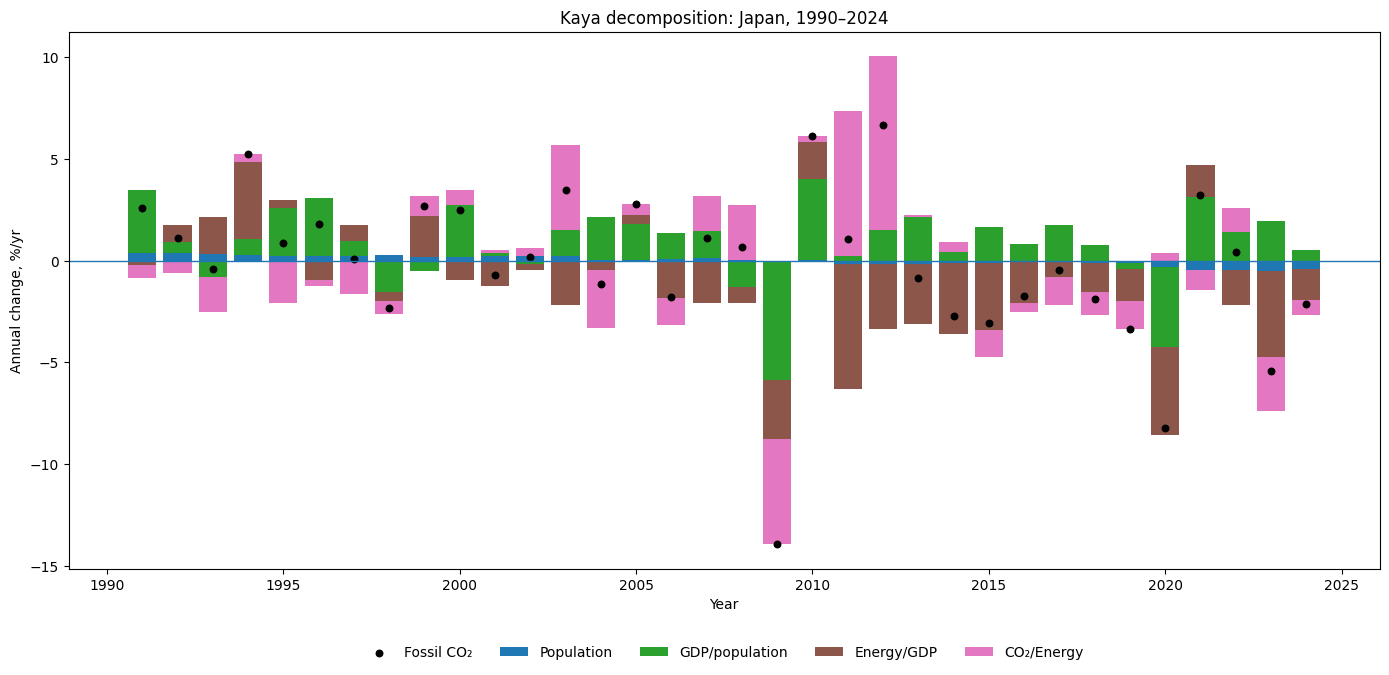

In [ ]:
plot = japan_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos,
           bottom=bottom_pos,
           label=label,
           color=color)

    ax.bar(plot["year"], neg,
           bottom=bottom_neg,
           color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: Japan, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "japan_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
jpn.to_csv("japan_full_dataset.csv", index=False)
japan_kaya.to_csv("japan_kaya_1990_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("japan_full_dataset.csv")
files.download("japan_kaya_1990_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Kaya decomposition for India

In [ ]:
country_name = "India"
country_code_wb = "IND"

In [ ]:
ind_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

ind_ei = ind_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

ind_ei = ind_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

ind_ei.head()

Var,year,co2_mt,energy_ej
0,1965,167.344660,2.094991
1,1966,169.901349,2.157278
2,1967,174.333504,2.212566
3,1968,182.399099,2.352236
4,1969,197.321583,2.607880


In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_ind = pd.DataFrame(data)

gdp_real_ind = gdp_real_ind[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_ind["year"] = gdp_real_ind["year"].astype(int)
gdp_real_ind = gdp_real_ind.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_ind = pd.DataFrame(data)

pop_ind = pop_ind[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_ind["year"] = pop_ind["year"].astype(int)
pop_ind = pop_ind.sort_values("year")

gdp_real_ind.head(), pop_ind.head()

(    year  gdp_real_2015_usd
 34  1990       4.652428e+11
 33  1991       4.701597e+11
 32  1992       4.959357e+11
 31  1993       5.194965e+11
 30  1994       5.540894e+11,
     year  population
 34  1990   864972221
 33  1991   883927600
 32  1992   902957070
 31  1993   922118387
 30  1994   941163767)

In [ ]:
ind = pd.merge(gdp_real_ind, pop_ind, on="year", how="inner")
ind = pd.merge(ind, ind_ei, on="year", how="inner")
ind = ind.sort_values("year").copy()

ind["gdp_per_capita"] = ind["gdp_real_2015_usd"] / ind["population"]
ind["energy_intensity"] = ind["energy_ej"] / ind["gdp_real_2015_usd"]
ind["carbon_intensity"] = ind["co2_mt"] / ind["energy_ej"]

ind_kaya = ind[(ind["year"] >= 1990) & (ind["year"] <= 2024)].copy()

ind_kaya["population_pp"] = 100 * np.log(ind_kaya["population"] / ind_kaya["population"].shift(1))
ind_kaya["gdp_per_capita_pp"] = 100 * np.log(ind_kaya["gdp_per_capita"] / ind_kaya["gdp_per_capita"].shift(1))
ind_kaya["energy_intensity_pp"] = 100 * np.log(ind_kaya["energy_intensity"] / ind_kaya["energy_intensity"].shift(1))
ind_kaya["carbon_intensity_pp"] = 100 * np.log(ind_kaya["carbon_intensity"] / ind_kaya["carbon_intensity"].shift(1))

ind_kaya["co2_growth_pct"] = 100 * np.log(ind_kaya["co2_mt"] / ind_kaya["co2_mt"].shift(1))

ind_kaya["sum_factors"] = (
    ind_kaya["population_pp"] +
    ind_kaya["gdp_per_capita_pp"] +
    ind_kaya["energy_intensity_pp"] +
    ind_kaya["carbon_intensity_pp"]
)

ind_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,5.307339,5.307339,2.167777,-1.116491,3.971679,0.284374
2,1992,5.669678,5.669678,2.129985,3.207404,0.318566,0.013723
3,1993,3.240279,3.240279,2.099861,2.541518,-2.104494,0.703396
4,1994,4.334051,4.334051,2.044354,4.402239,-1.647332,-0.465210
5,1995,6.494075,6.494075,2.012966,5.288371,0.616230,-1.423492
6,1996,4.923969,4.923969,1.997759,5.280364,-2.718975,0.364821
7,1997,5.101665,5.101665,1.966425,2.003539,1.581722,-0.450022
8,1998,4.652834,4.652834,1.935964,4.064753,-0.648217,-0.699666
9,1999,2.056246,2.056246,1.902029,6.574132,-5.506035,-0.913880


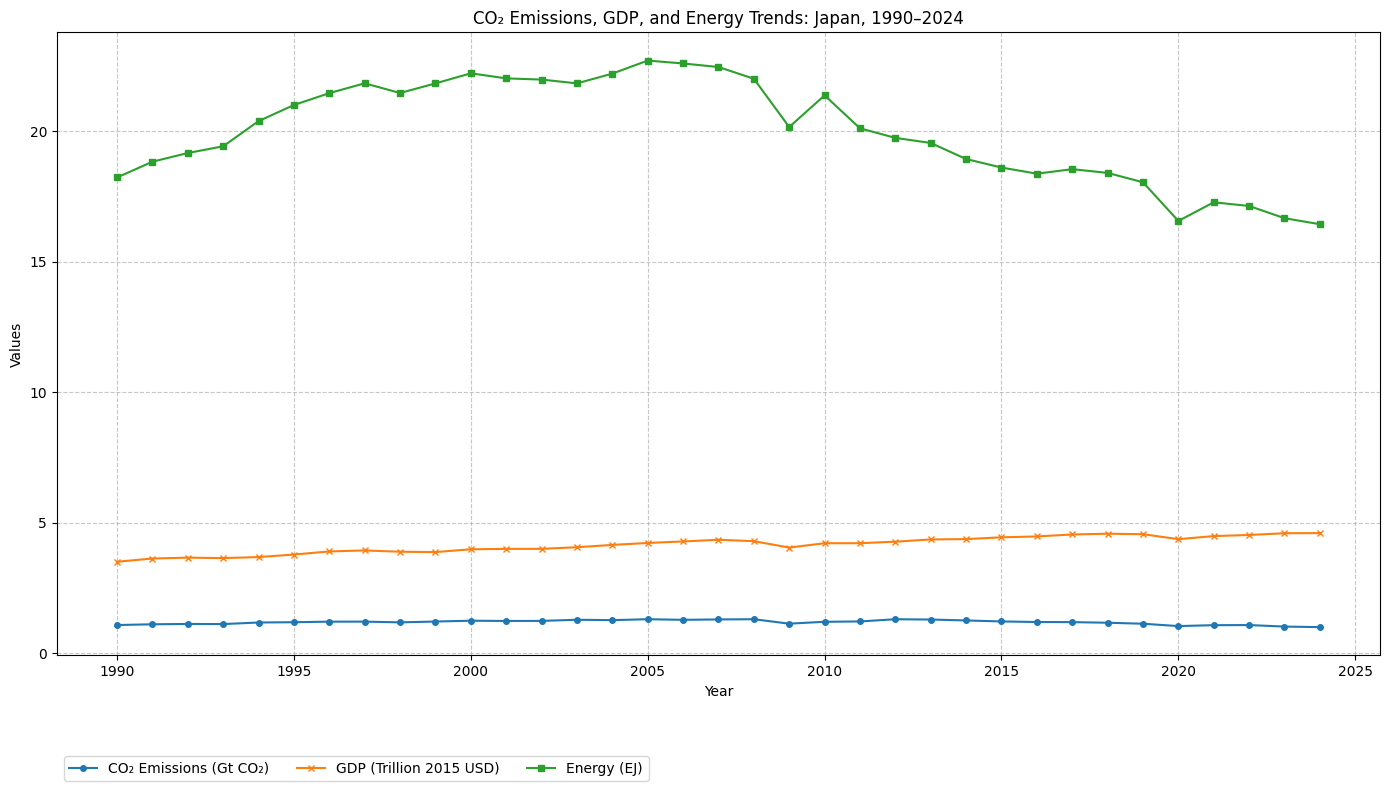

In [ ]:
jpn_plot = jpn.copy()

# Convert units for better readability in the plot
jpn_plot["co2_gt"] = jpn_plot["co2_mt"] / 1000  # Convert Mt CO2 to Gt CO2
jpn_plot["gdp_trillion_usd"] = jpn_plot["gdp_real_2015_usd"] / 1e12 # Convert real GDP to trillion USD
jpn_plot["energy_ej"] = jpn_plot["energy_ej"]

plt.figure(figsize=(14, 8))

# Plot CO2 emissions
plt.plot(jpn_plot["year"][jpn_plot["year"] >= 1990], jpn_plot["co2_gt"][jpn_plot["year"] >= 1990], label="CO₂ Emissions (Gt CO₂)", marker='o', markersize=4)
# Plot GDP
plt.plot(jpn_plot["year"][jpn_plot["year"] >= 1990], jpn_plot["gdp_trillion_usd"][jpn_plot["year"] >= 1990], label="GDP (Trillion 2015 USD)", marker='x', markersize=4)
# Plot Energy
plt.plot(jpn_plot["year"][jpn_plot["year"] >= 1990], jpn_plot["energy_ej"][jpn_plot["year"] >= 1990], label="Energy (EJ)", marker='s', markersize=4)

plt.title("CO₂ Emissions, GDP, and Energy Trends: Japan, 1990–2024")
plt.xlabel("Year")
plt.ylabel("Values")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', bbox_to_anchor=(0.0, -0.15), ncol=3)
plt.tight_layout()

plt.savefig("japan_co2_gdp_energy_plot.png", dpi=300, bbox_inches="tight")

plt.show()

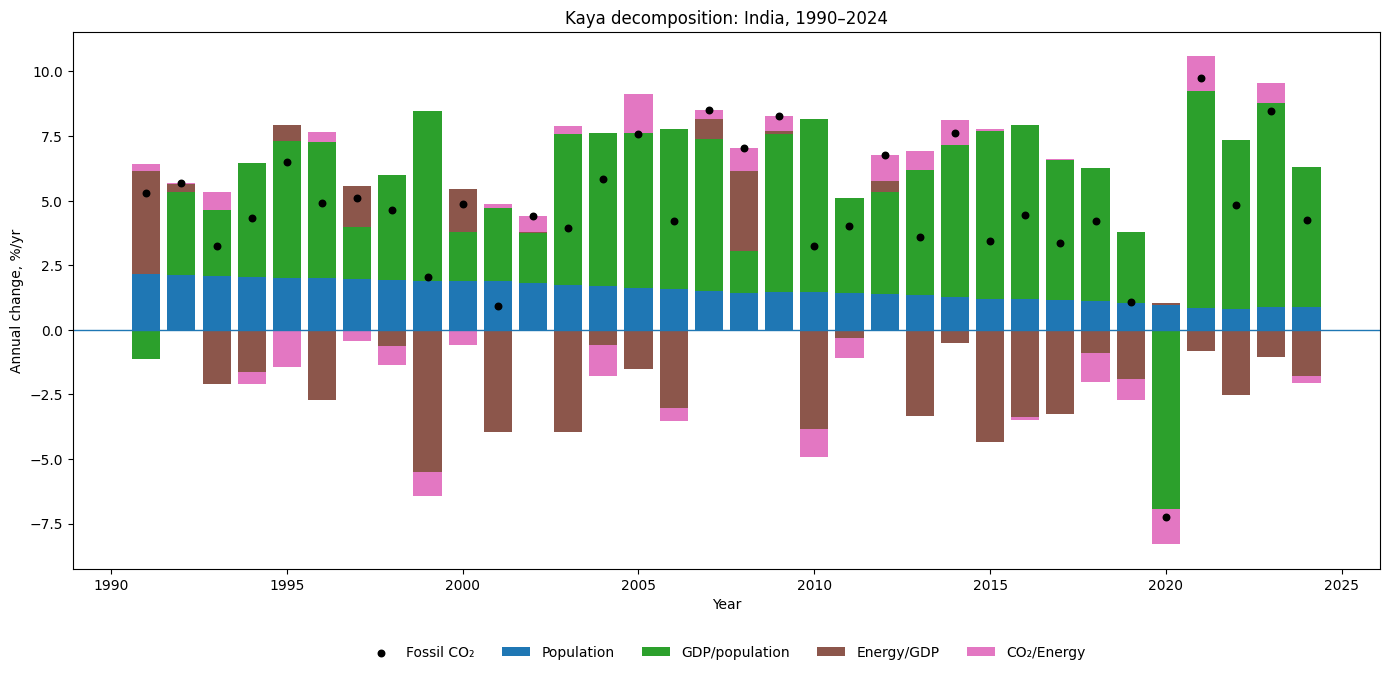

In [ ]:
plot = ind_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos,
           bottom=bottom_pos,
           label=label,
           color=color)

    ax.bar(plot["year"], neg,
           bottom=bottom_neg,
           color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: India, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "india_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kaya decomposition for India

![Kaya decomposition: India](india_kaya_decomposition.png)

In [ ]:
ind.to_csv("india_full_dataset.csv", index=False)
ind_kaya.to_csv("india_kaya_1990_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("india_full_dataset.csv")
files.download("india_kaya_1990_2024.csv")
files.download("india_kaya_decomposition.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Kaya decomposition for European Union (EU27)

In [ ]:
print([c for c in sorted(ei["Country"].unique()) if "Europe" in c or "Union" in c or "EU" in c])

['Other Europe', 'Total EU', 'Total Europe']


In [ ]:
country_name = "Total EU"
country_code_wb = "EUU"

In [ ]:
eu_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

eu_ei = eu_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

eu_ei = eu_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

eu_ei.head()

Var,year,co2_mt,energy_ej
0,1965,2629.162499,32.611914
1,1966,2675.214528,33.637953
2,1967,2753.867892,34.914399
3,1968,2934.730350,37.462145
4,1969,3158.761224,40.714281


In [ ]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_eu = pd.DataFrame(data)

gdp_real_eu = gdp_real_eu[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_eu["year"] = gdp_real_eu["year"].astype(int)
gdp_real_eu = gdp_real_eu.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_eu = pd.DataFrame(data)

pop_eu = pop_eu[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_eu["year"] = pop_eu["year"].astype(int)
pop_eu = pop_eu.sort_values("year")

gdp_real_eu.head(), pop_eu.head()

(    year  gdp_real_2015_usd
 34  1990       9.138536e+12
 33  1991       9.271989e+12
 32  1992       9.355591e+12
 31  1993       9.299829e+12
 30  1994       9.551055e+12,
     year  population
 34  1990   420525030
 33  1991   421741276
 32  1992   422968989
 31  1993   424344744
 30  1994   425404352)

In [ ]:
eu = pd.merge(gdp_real_eu, pop_eu, on="year", how="inner")
eu = pd.merge(eu, eu_ei, on="year", how="inner")
eu = eu.sort_values("year").copy()

eu["gdp_per_capita"] = eu["gdp_real_2015_usd"] / eu["population"]
eu["energy_intensity"] = eu["energy_ej"] / eu["gdp_real_2015_usd"]
eu["carbon_intensity"] = eu["co2_mt"] / eu["energy_ej"]

eu_kaya = eu[(eu["year"] >= 1990) & (eu["year"] <= 2024)].copy()

eu_kaya["population_pp"] = 100 * np.log(eu_kaya["population"] / eu_kaya["population"].shift(1))
eu_kaya["gdp_per_capita_pp"] = 100 * np.log(eu_kaya["gdp_per_capita"] / eu_kaya["gdp_per_capita"].shift(1))
eu_kaya["energy_intensity_pp"] = 100 * np.log(eu_kaya["energy_intensity"] / eu_kaya["energy_intensity"].shift(1))
eu_kaya["carbon_intensity_pp"] = 100 * np.log(eu_kaya["carbon_intensity"] / eu_kaya["carbon_intensity"].shift(1))

eu_kaya["co2_growth_pct"] = 100 * np.log(eu_kaya["co2_mt"] / eu_kaya["co2_mt"].shift(1))

eu_kaya["sum_factors"] = (
    eu_kaya["population_pp"] +
    eu_kaya["gdp_per_capita_pp"] +
    eu_kaya["energy_intensity_pp"] +
    eu_kaya["carbon_intensity_pp"]
)

eu_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,-2.327071,-2.327071,0.288803,1.160971,-2.449611,-1.327235
2,1992,-3.193084,-3.193084,0.290683,0.606933,-2.783589,-1.307111
3,1993,-1.597292,-1.597292,0.324734,-0.922542,-0.213075,-0.786410
4,1994,-1.280327,-1.280327,0.249393,2.416165,-3.112947,-0.832938
5,1995,2.018985,2.018985,0.189217,2.499005,0.073574,-0.742811
6,1996,2.743216,2.743216,0.162952,1.734994,1.330874,-0.485605
7,1997,-1.556818,-1.556818,0.150393,2.498706,-3.382302,-0.823615
8,1998,-0.067841,-0.067841,0.133803,2.804028,-2.399649,-0.606023
9,1999,-1.471496,-1.471496,0.164735,2.794783,-3.629209,-0.801805


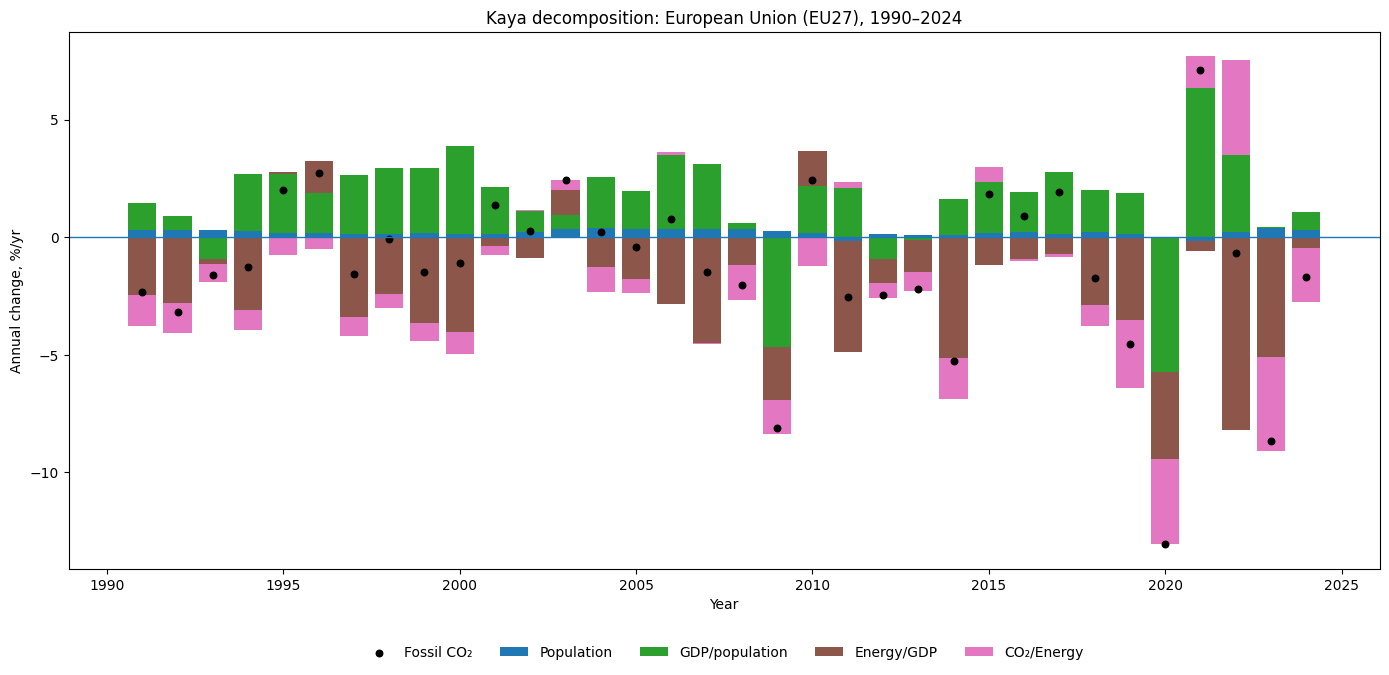

In [ ]:
plot = eu_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos,
           bottom=bottom_pos,
           label=label,
           color=color)

    ax.bar(plot["year"], neg,
           bottom=bottom_neg,
           color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: European Union (EU27), 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "eu_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kaya decomposition for European Union (EU27)

![Kaya decomposition: European Union (EU27)](eu_kaya_decomposition.png)

In [ ]:
eu.to_csv("eu_full_dataset.csv", index=False)
eu_kaya.to_csv("eu_kaya_1990_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("eu_full_dataset.csv")
files.download("eu_kaya_1990_2024.csv")
files.download("eu_kaya_decomposition.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
eu = pd.merge(gdp_real_eu, pop_eu, on="year", how="inner")
eu = pd.merge(eu, eu_ei, on="year", how="inner")
eu = eu.sort_values("year").copy()

eu["gdp_per_capita"] = eu["gdp_real_2015_usd"] / eu["population"]
eu["energy_intensity"] = eu["energy_ej"] / eu["gdp_real_2015_usd"]
eu["carbon_intensity"] = eu["co2_mt"] / eu["energy_ej"]

eu_kaya = eu[(eu["year"] >= 1990) & (eu["year"] <= 2024)].copy()

eu_kaya["population_pp"] = 100 * np.log(eu_kaya["population"] / eu_kaya["population"].shift(1))
eu_kaya["gdp_per_capita_pp"] = 100 * np.log(eu_kaya["gdp_per_capita"] / eu_kaya["gdp_per_capita"].shift(1))
eu_kaya["energy_intensity_pp"] = 100 * np.log(eu_kaya["energy_intensity"] / eu_kaya["energy_intensity"].shift(1))
eu_kaya["carbon_intensity_pp"] = 100 * np.log(eu_kaya["carbon_intensity"] / eu_kaya["carbon_intensity"].shift(1))

eu_kaya["co2_growth_pct"] = 100 * np.log(eu_kaya["co2_mt"] / eu_kaya["co2_mt"].shift(1))

eu_kaya["sum_factors"] = (
    eu_kaya["population_pp"] +
    eu_kaya["gdp_per_capita_pp"] +
    eu_kaya["energy_intensity_pp"] +
    eu_kaya["carbon_intensity_pp"]
)

eu_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,-2.327071,-2.327071,0.288803,1.160971,-2.449611,-1.327235
2,1992,-3.193084,-3.193084,0.290683,0.606933,-2.783589,-1.307111
3,1993,-1.597292,-1.597292,0.324734,-0.922542,-0.213075,-0.786410
4,1994,-1.280327,-1.280327,0.249393,2.416165,-3.112947,-0.832938
5,1995,2.018985,2.018985,0.189217,2.499005,0.073574,-0.742811
6,1996,2.743216,2.743216,0.162952,1.734994,1.330874,-0.485605
7,1997,-1.556818,-1.556818,0.150393,2.498706,-3.382302,-0.823615
8,1998,-0.067841,-0.067841,0.133803,2.804028,-2.399649,-0.606023
9,1999,-1.471496,-1.471496,0.164735,2.794783,-3.629209,-0.801805


In [ ]:
display(combined_kaya_plots.head())

,year,gdp_real_2015_usd,population,co2_mt,energy_ej,gdp_per_capita,energy_intensity,carbon_intensity,co2_check,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp,co2_growth_pct,sum_factors,country
0,1990,1.041272e+12,1135185000,2308.792723,27.686203,917.270662,2.658883e-11,83.391453,2308.792723,NaN,NaN,NaN,NaN,NaN,NaN,China
1,1991,1.138753e+12,1150780000,2439.954363,29.138333,989.548541,2.558794e-11,83.736924,2439.954363,1.364434,7.584623,-3.837020,0.413421,5.525458,5.525458,China
2,1992,1.301590e+12,1164970000,2562.756190,30.666430,1117.273295,2.356075e-11,83.568782,2562.756190,1.225536,12.139762,-8.253900,-0.201000,4.910398,4.910398,China
3,1993,1.482889e+12,1178440000,2769.614442,32.980124,1258.349461,2.224045e-11,83.978290,2769.614442,1.149619,11.890975,-5.766942,0.488828,7.762480,7.762480,China
4,1994,1.676743e+12,1191835000,2921.357668,35.006294,1406.858457,2.087755e-11,83.452354,2921.357668,1.130261,11.155826,-6.323808,-0.628245,5.334034,5.334034,China


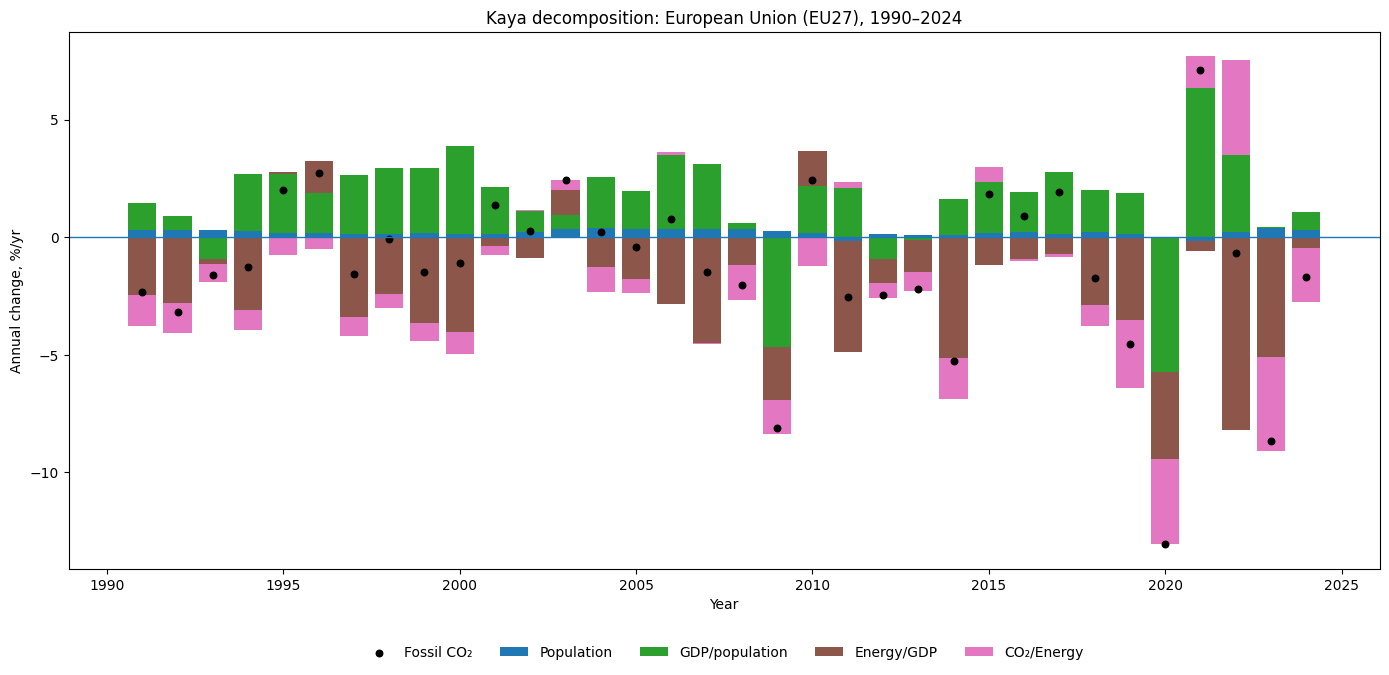

In [ ]:
plot = eu_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos,
           bottom=bottom_pos,
           label=label,
           color=color)

    ax.bar(plot["year"], neg,
           bottom=bottom_neg,
           color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: European Union (EU27), 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "eu_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kaya decomposition for European Union (EU27)

![Kaya decomposition: European Union (EU27)](eu_kaya_decomposition.png)

In [ ]:
eu.to_csv("eu_full_dataset.csv", index=False)
eu_kaya.to_csv("eu_kaya_1990_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("eu_full_dataset.csv")
files.download("eu_kaya_1990_2024.csv")
files.download("eu_kaya_decomposition.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>